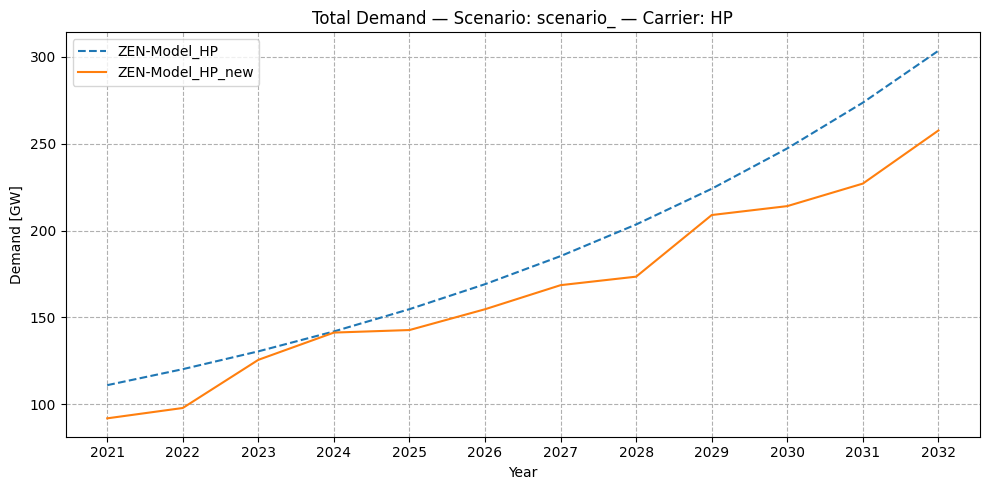

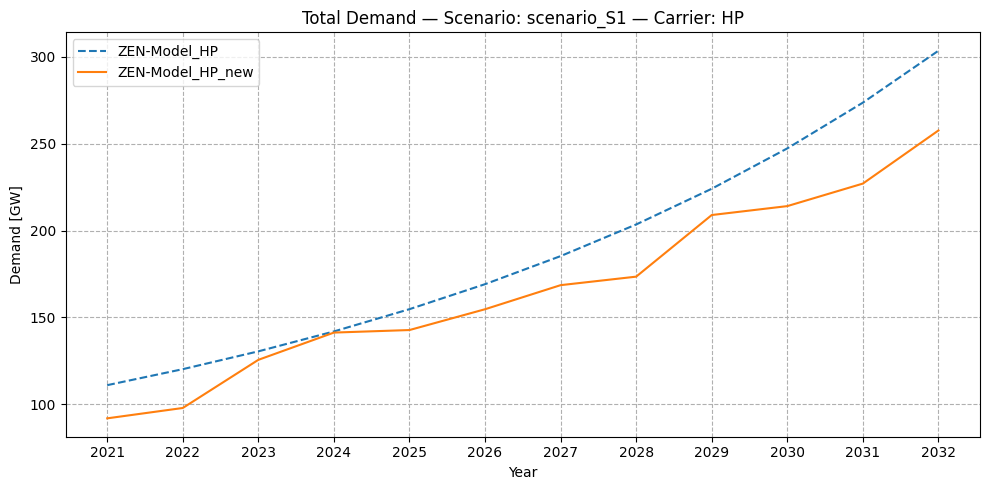

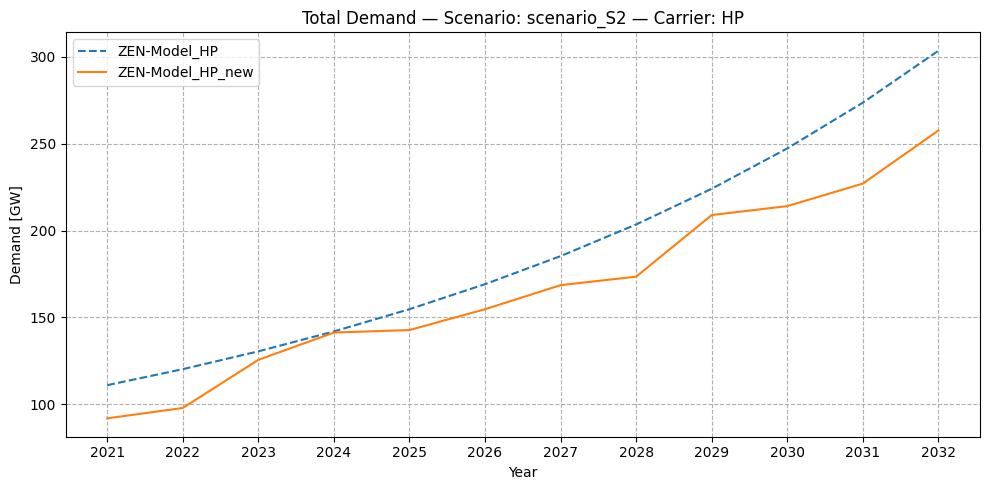

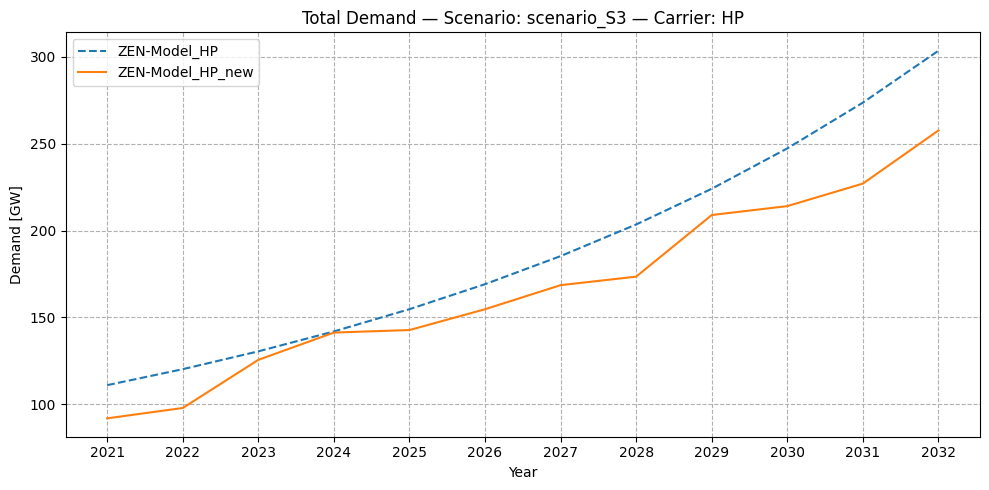

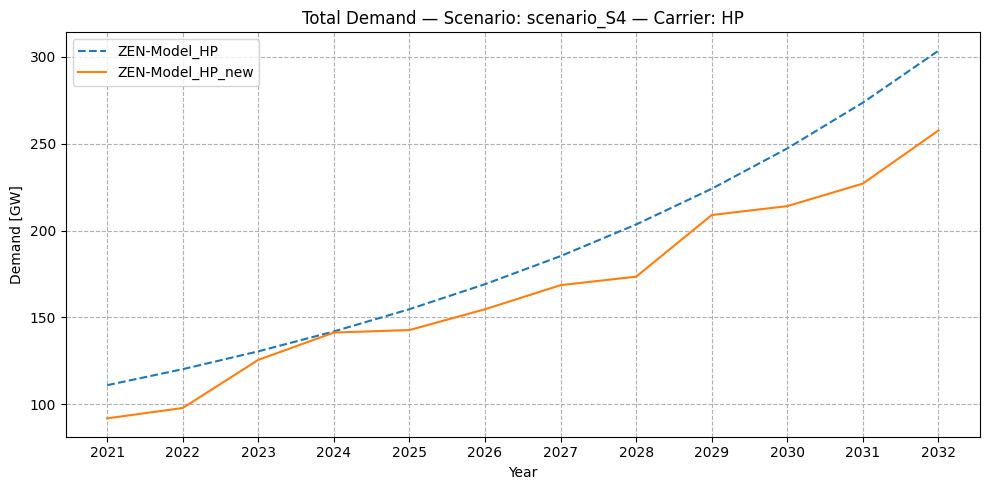

In [1]:
import os
from zen_garden.postprocess.results import Results
import pandas as pd
import matplotlib.pyplot as plt

# Dataset names
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'

# Load results
output_path_1 = os.path.join("outputs", dataset_name_1)
output_path_2 = os.path.join("outputs", dataset_name_2)

r1 = Results(output_path_1)
r2 = Results(output_path_2)

# Get and clean demand data
demand1 = r1.get_full_ts("demand").reset_index()
demand2 = r2.get_full_ts("demand").reset_index()

demand1 = demand1.rename(columns={"level_0": "scenario"})
demand2 = demand2.rename(columns={"level_0": "scenario"})

# Time step columns
time_cols = [col for col in demand1.columns if isinstance(col, (int, float))]
times = time_cols

# Get all scenarios from first dataset (assuming both share same scenarios)
scenarios = demand1["scenario"].unique()

for scenario in scenarios:
    d1_s = demand1[demand1["scenario"] == scenario]
    d2_s = demand2[demand2["scenario"] == scenario]

    # Group by carrier
    d1_grouped = d1_s.groupby("carrier")[times].sum()
    d2_grouped = d2_s.groupby("carrier")[times].sum()

    # Only continue if HP exists and has non-zero values in either
    if "HP" in d1_grouped.index or "HP" in d2_grouped.index:
        d1_hp = d1_grouped.loc["HP"] if "HP" in d1_grouped.index else pd.Series([0] * len(times), index=times)
        d2_hp = d2_grouped.loc["HP"] if "HP" in d2_grouped.index else pd.Series([0] * len(times), index=times)

        if d1_hp.sum() > 0 or d2_hp.sum() > 0:
            plt.figure(figsize=(10, 5))
            plt.plot(times, d1_hp, label=f"{dataset_name_1}", linestyle="--")
            plt.plot(times, d2_hp, label=f"{dataset_name_2}", linestyle="-")
            plt.title(f"Total Demand — Scenario: {scenario} — Carrier: HP")
            plt.xlabel("Year")
            plt.ylabel("Demand [GW]")
            plt.grid(True, linestyle="--")
            plt.legend()
            plt.tight_layout()

            # Custom xticks
            step_interval = 1  # adjust to 5 if you want yearly spacing
            xticks_positions = times[::step_interval]
            xticks_labels = [str(2021 + i) for i in range(len(xticks_positions))]
            plt.xticks(ticks=xticks_positions, labels=xticks_labels)

            plt.show()


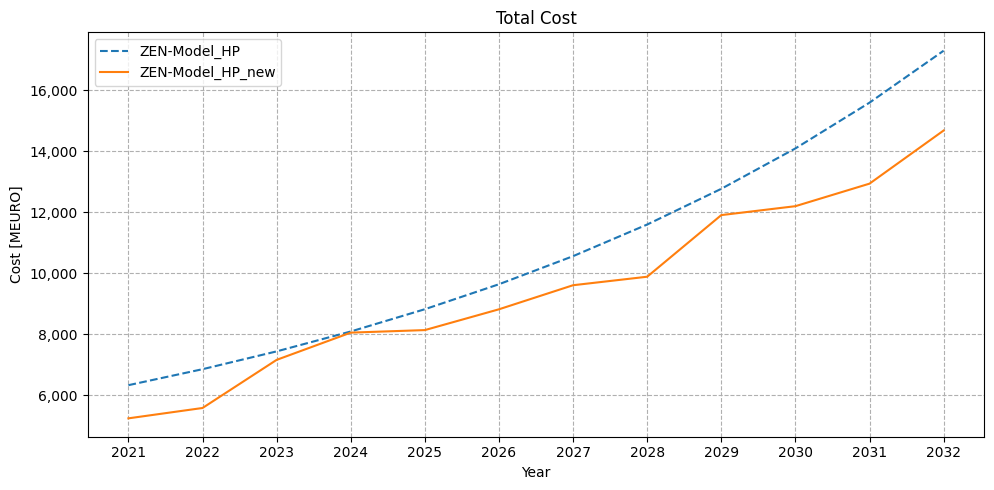

In [2]:
import os
from zen_garden.postprocess.results import Results
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Dataset names
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'

# Load results
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# Load cost_total and reset index
cost1 = r1.get_full_ts("cost_total").reset_index()
cost2 = r2.get_full_ts("cost_total").reset_index()

# Rename index column for clarity
cost1 = cost1.rename(columns={"index": "component"})
cost2 = cost2.rename(columns={"index": "component"})

# Identify time step columns (float or int)
time_cols = [col for col in cost1.columns if isinstance(col, (int, float))]
times = time_cols

# Sum across all components and convert from kEUR to MEUR
c1_total = cost1[time_cols].sum() / 1000
c2_total = cost2[time_cols].sum() / 1000

# Plot
plt.figure(figsize=(10, 5))
plt.plot(times, c1_total, label=dataset_name_1, linestyle="--")
plt.plot(times, c2_total, label=dataset_name_2, linestyle="-")
plt.title("Total Cost")
plt.xlabel("Year")
plt.ylabel("Cost [MEURO]")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()

# Format y-axis to show whole numbers
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# X-axis ticks (e.g., 1 tick per year)
step_interval = 1
xticks_positions = times[::step_interval]
xticks_labels = [str(2021 + i) for i in range(len(xticks_positions))]
plt.xticks(ticks=xticks_positions, labels=xticks_labels)

plt.show()


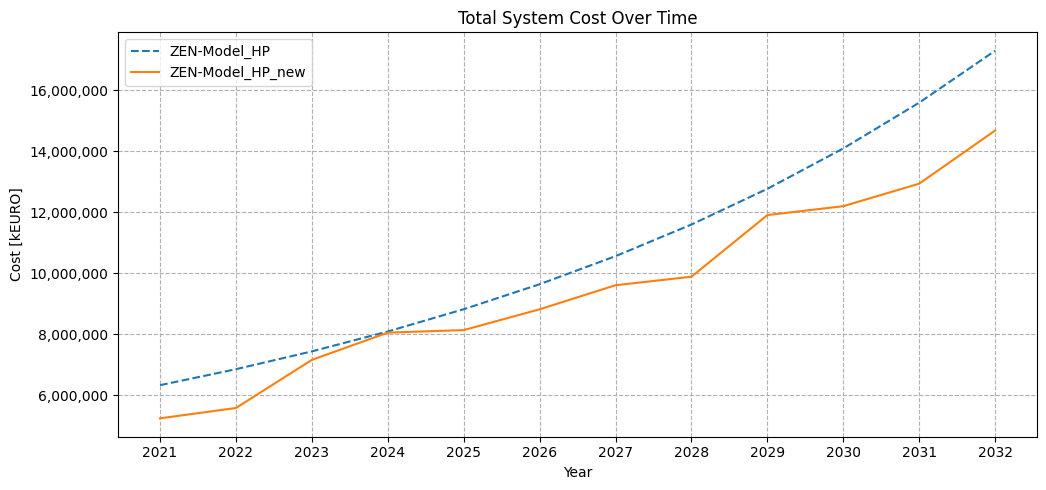

In [3]:
import os
from zen_garden.postprocess.results import Results
import pandas as pd
import matplotlib.pyplot as plt

# Dataset names
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'

# Load results
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# Load cost_total and reset index
cost1 = r1.get_full_ts("cost_total").reset_index()
cost2 = r2.get_full_ts("cost_total").reset_index()

# Rename index column for clarity
cost1 = cost1.rename(columns={"index": "component"})
cost2 = cost2.rename(columns={"index": "component"})

# Identify time step columns
time_cols = [col for col in cost1.columns if isinstance(col, (int, float))]
times = time_cols

# Sum across all components (e.g., carriers, regions, technologies)
c1_total = cost1[time_cols].sum()
c2_total = cost2[time_cols].sum()

import matplotlib.ticker as ticker

# Plot
plt.figure(figsize=(10, 5))
plt.plot(times, c1_total, label=dataset_name_1, linestyle="--")
plt.plot(times, c2_total, label=dataset_name_2, linestyle="-")
plt.title("Total System Cost Over Time")
plt.xlabel("Year")
plt.ylabel("Cost [kEURO]")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()

# Format y-axis to show whole numbers
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# X-axis ticks (e.g., 1 tick per year)
step_interval = 1
xticks_positions = times[::step_interval]
xticks_labels = [str(2021 + i) for i in range(len(xticks_positions))]
plt.xticks(ticks=xticks_positions, labels=xticks_labels)

plt.show()



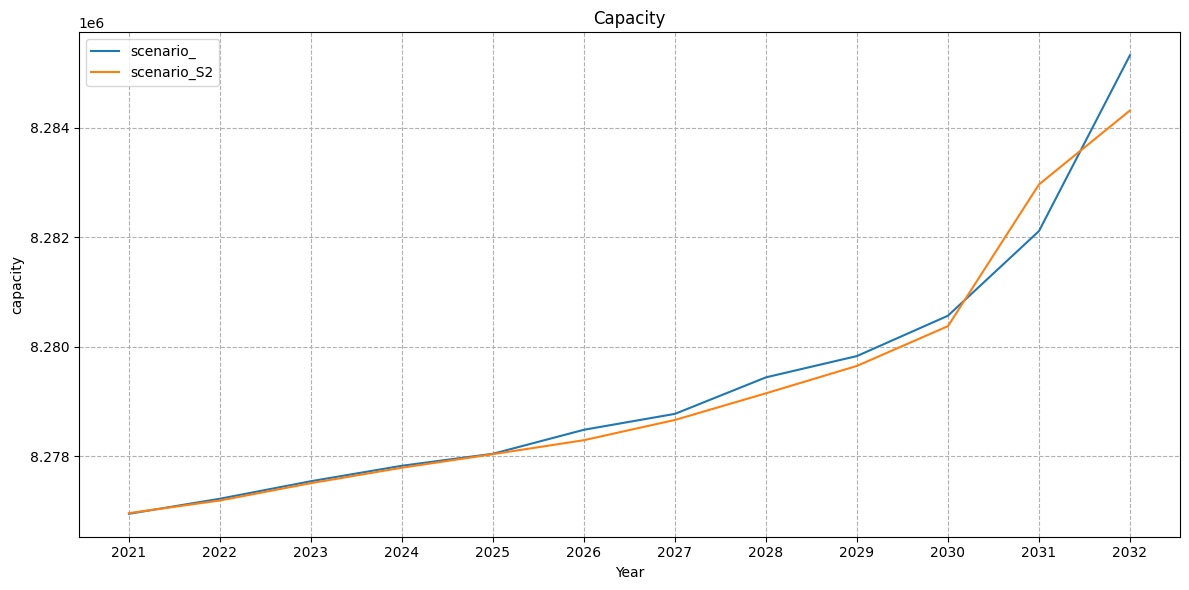

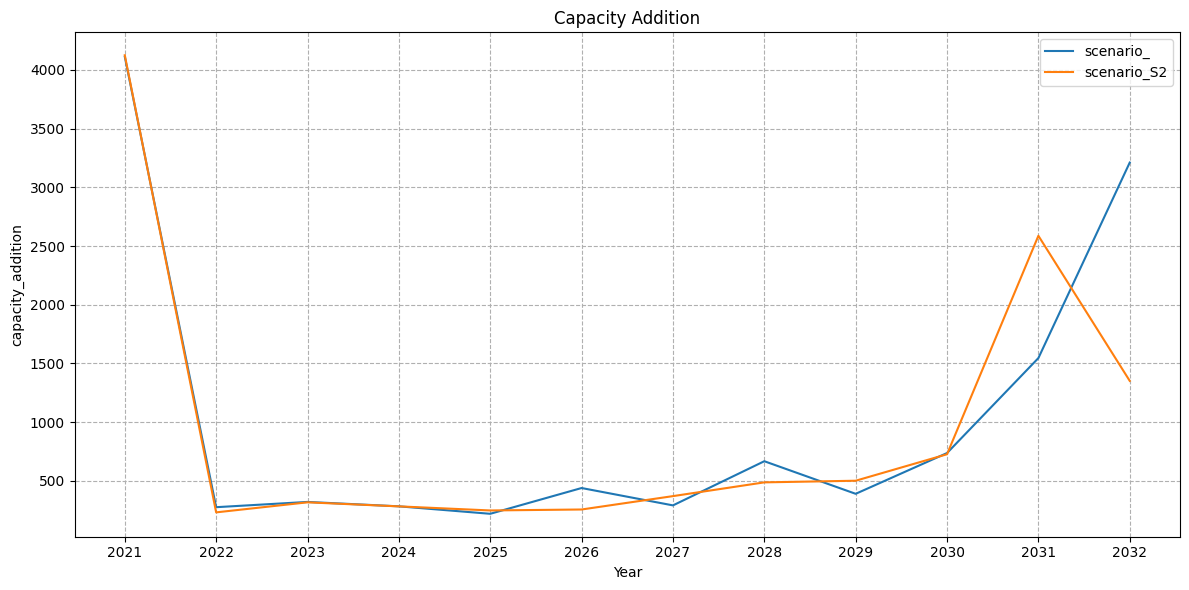

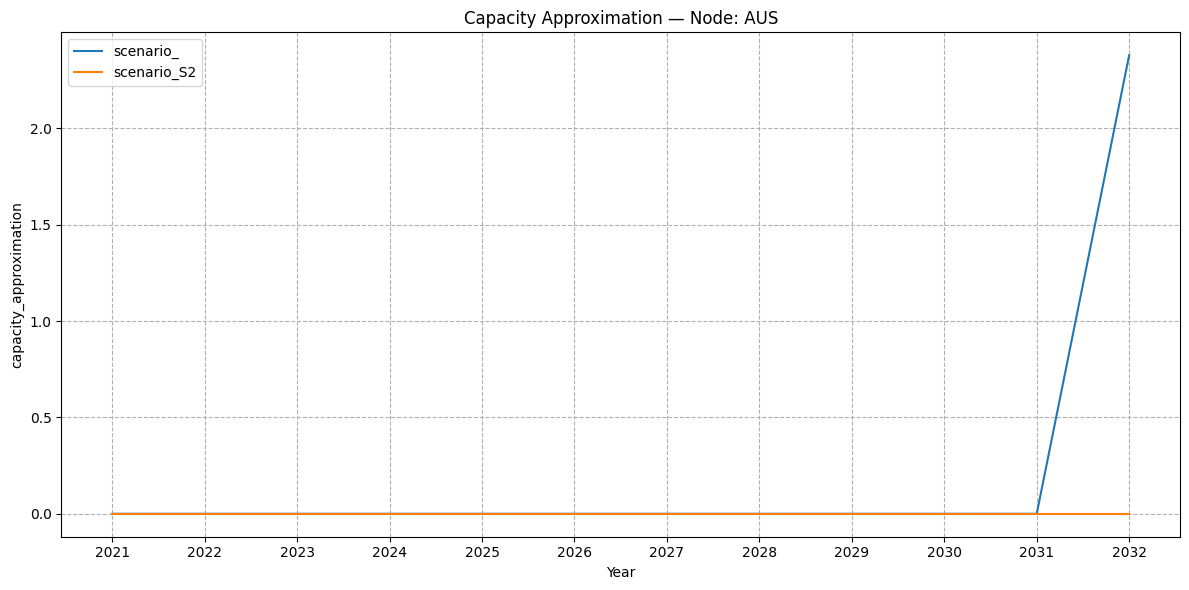

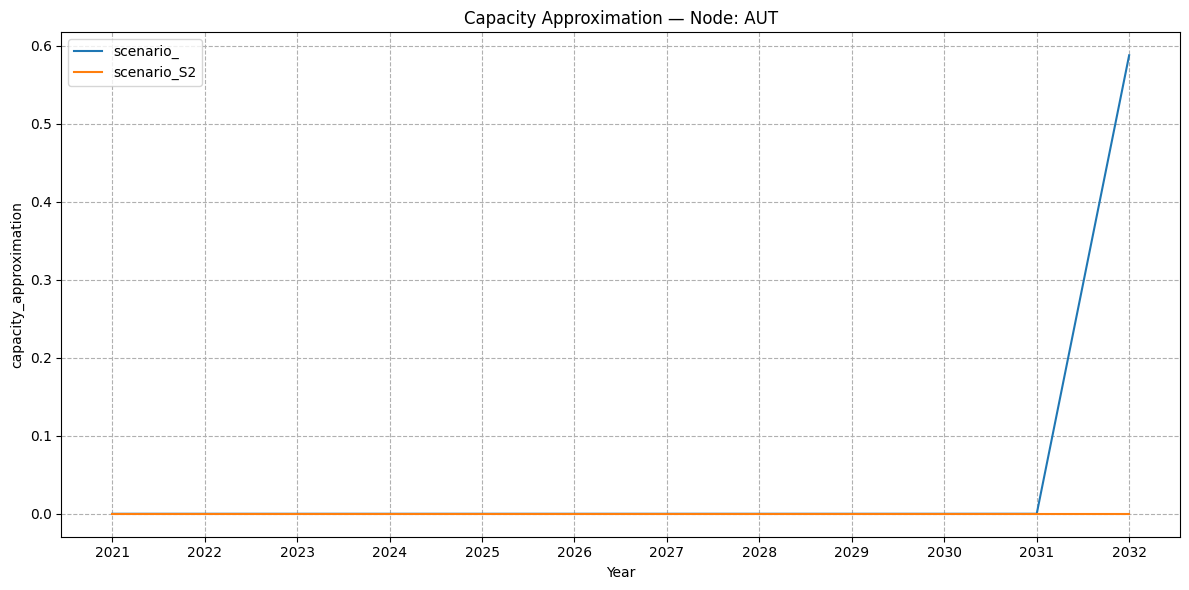

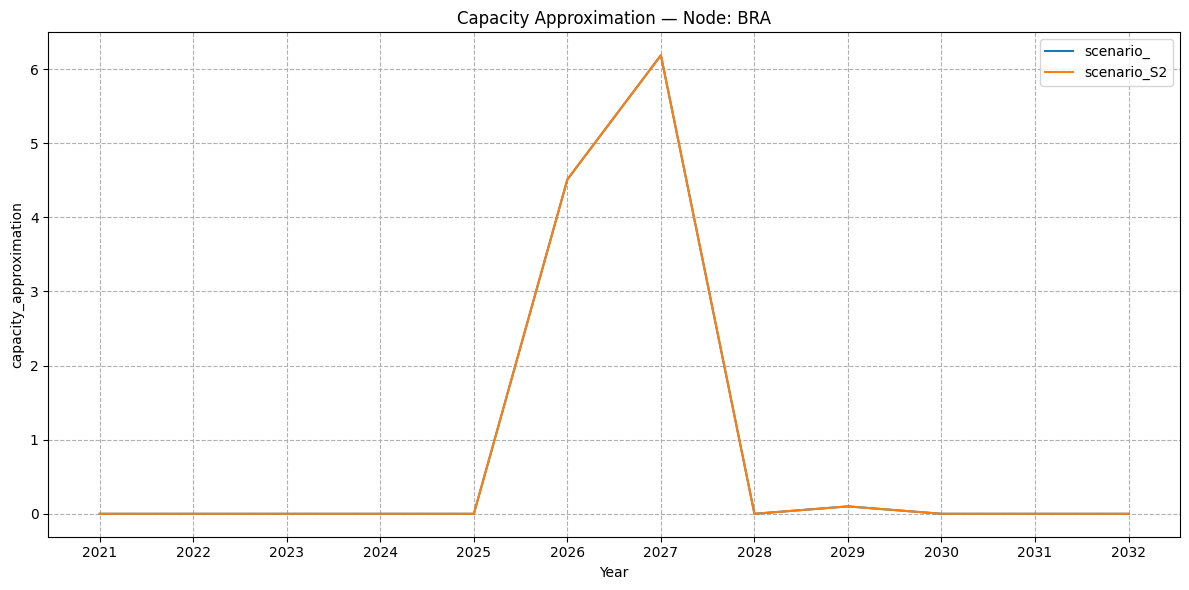

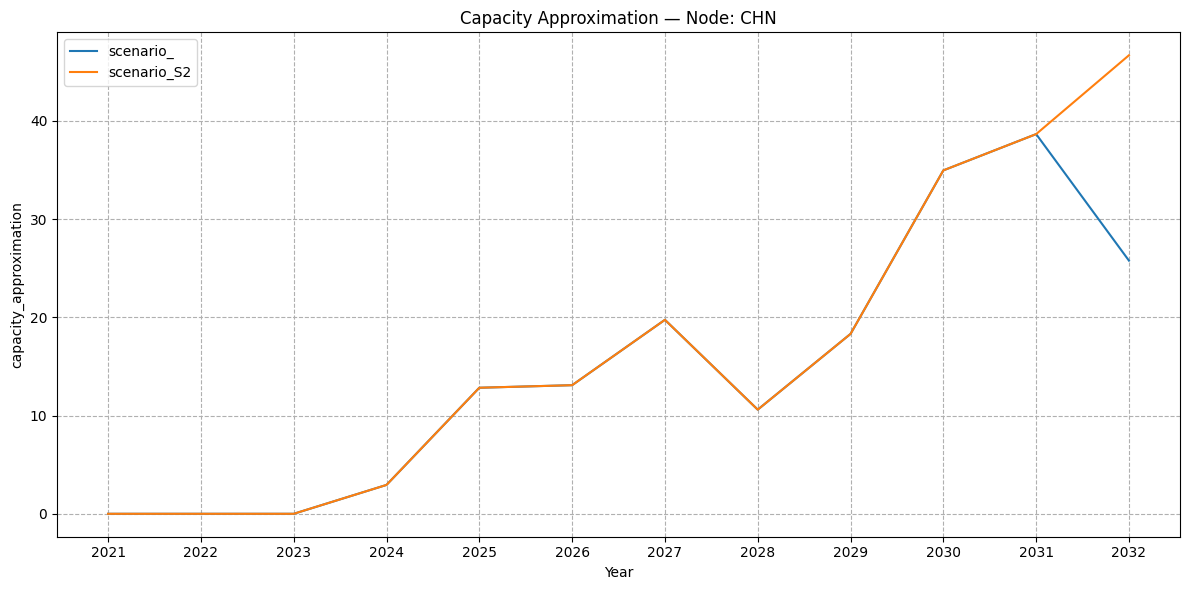

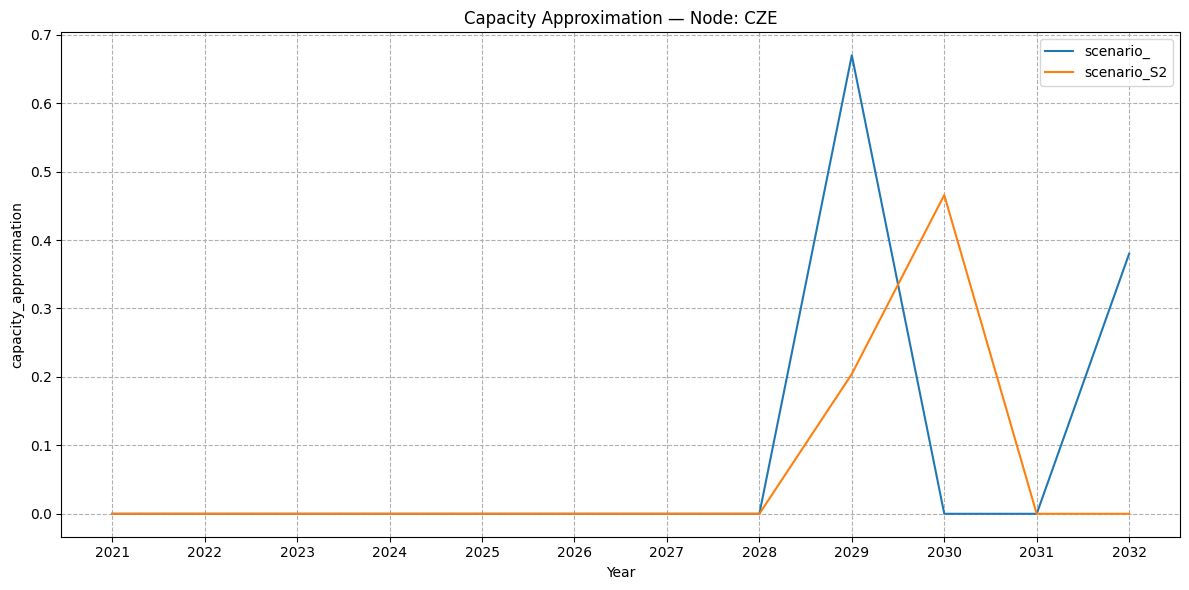

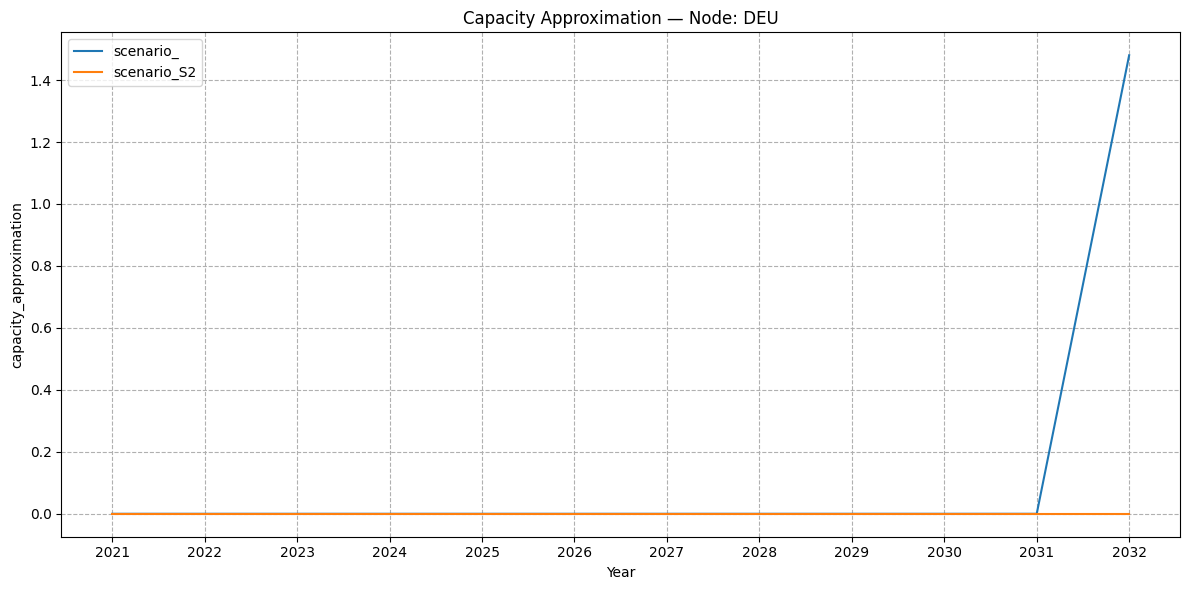

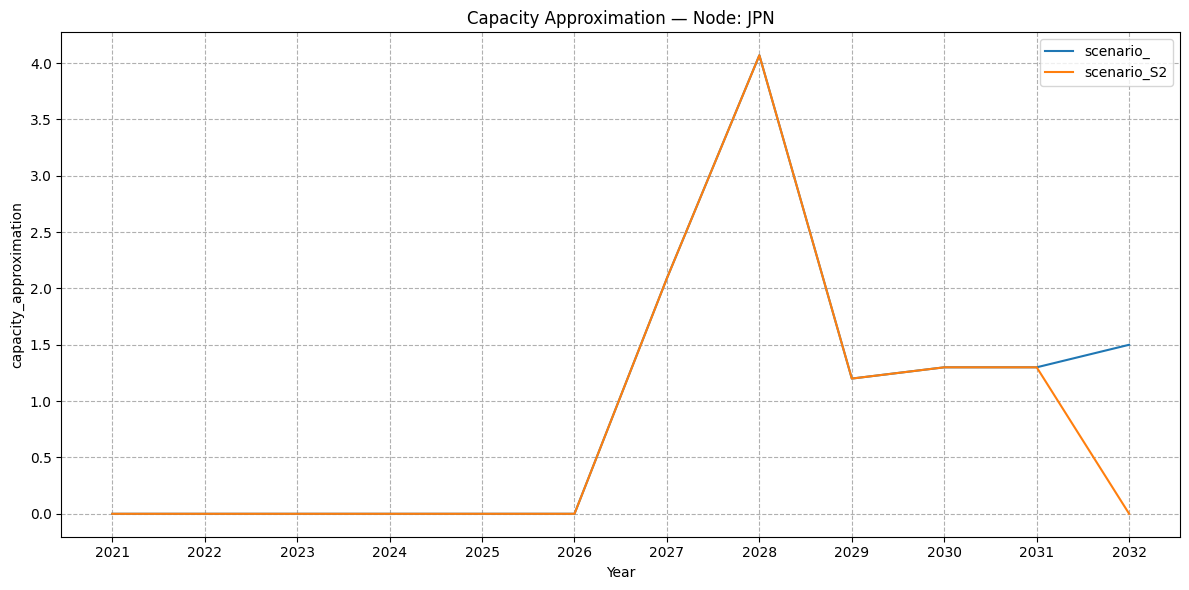

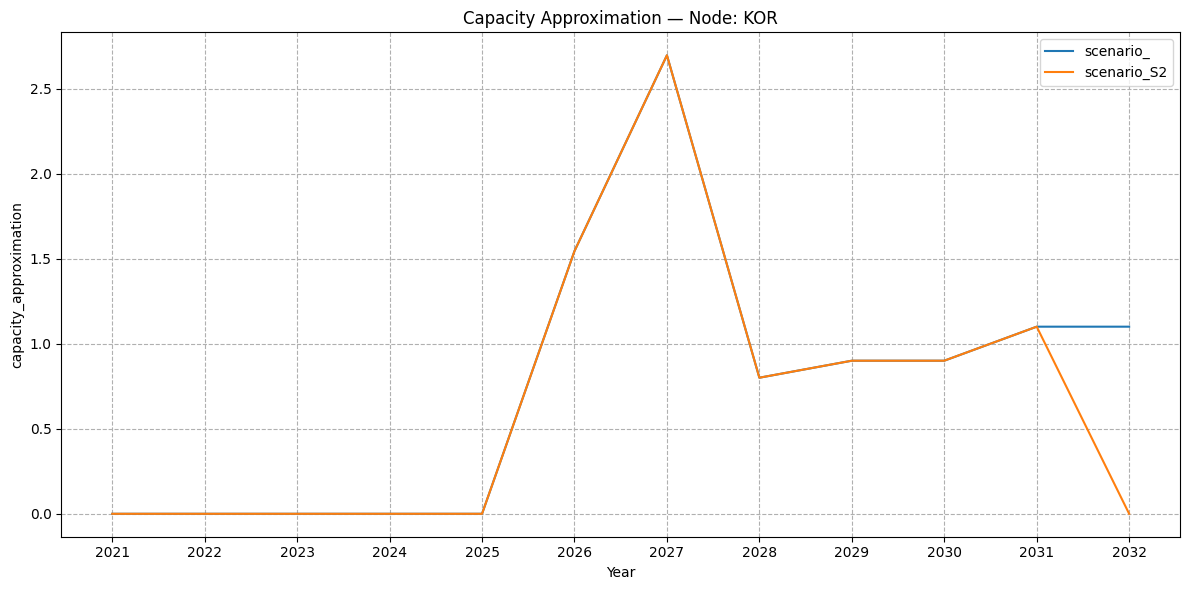

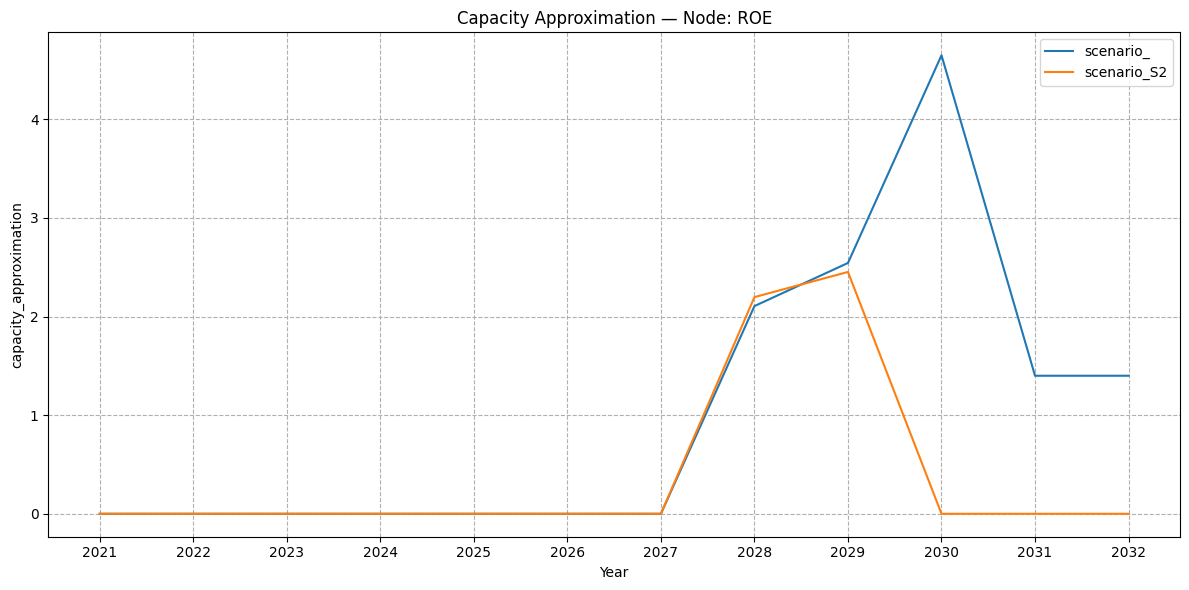

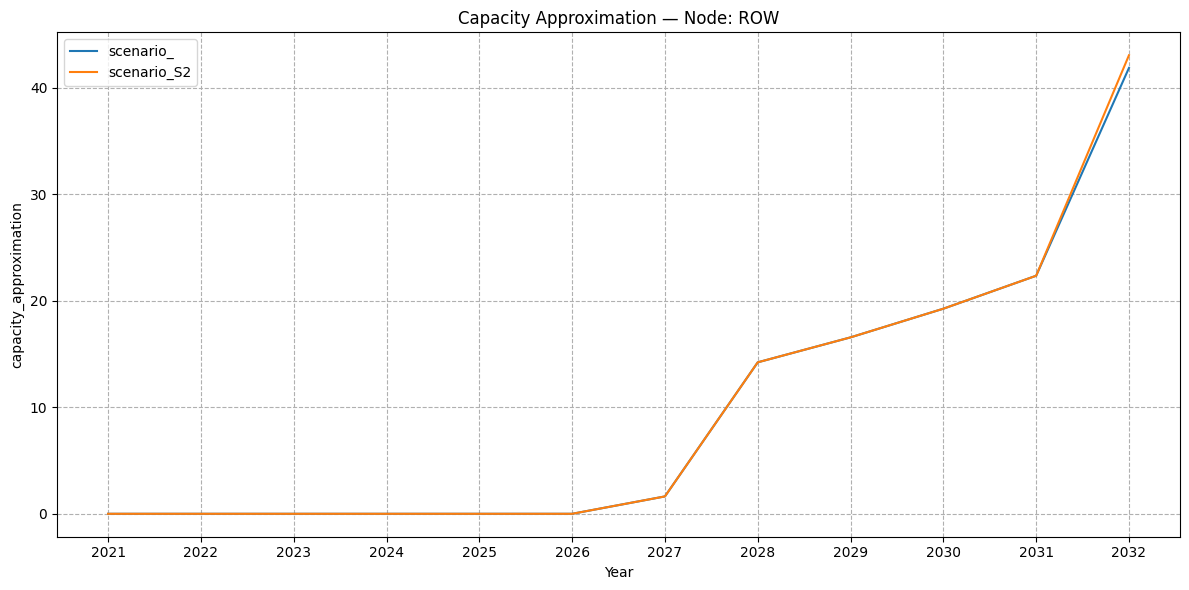

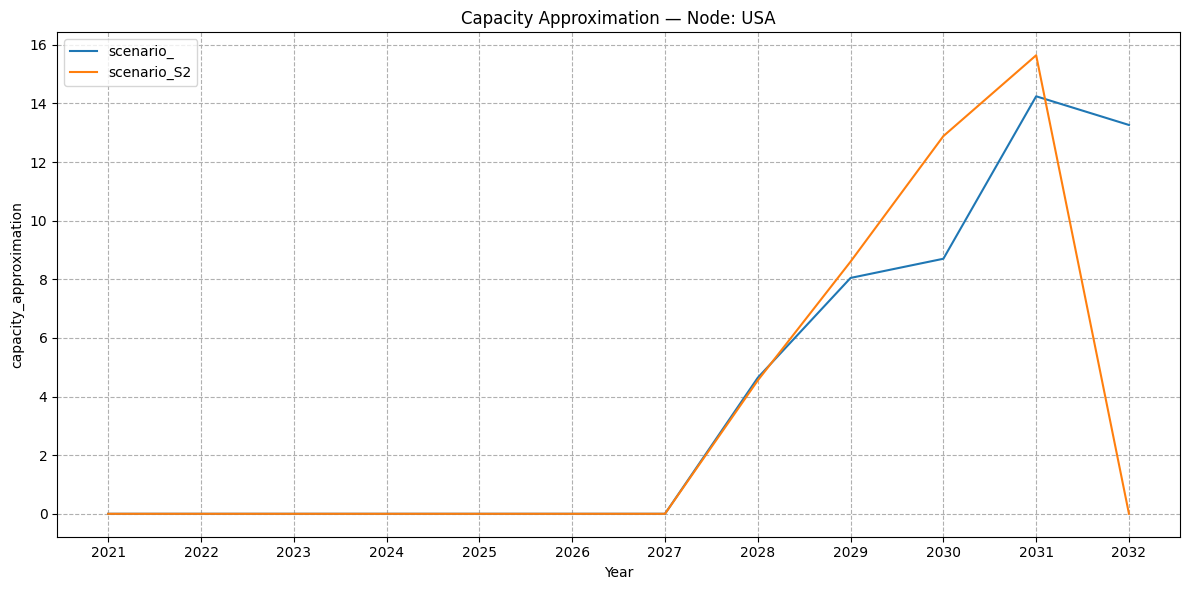

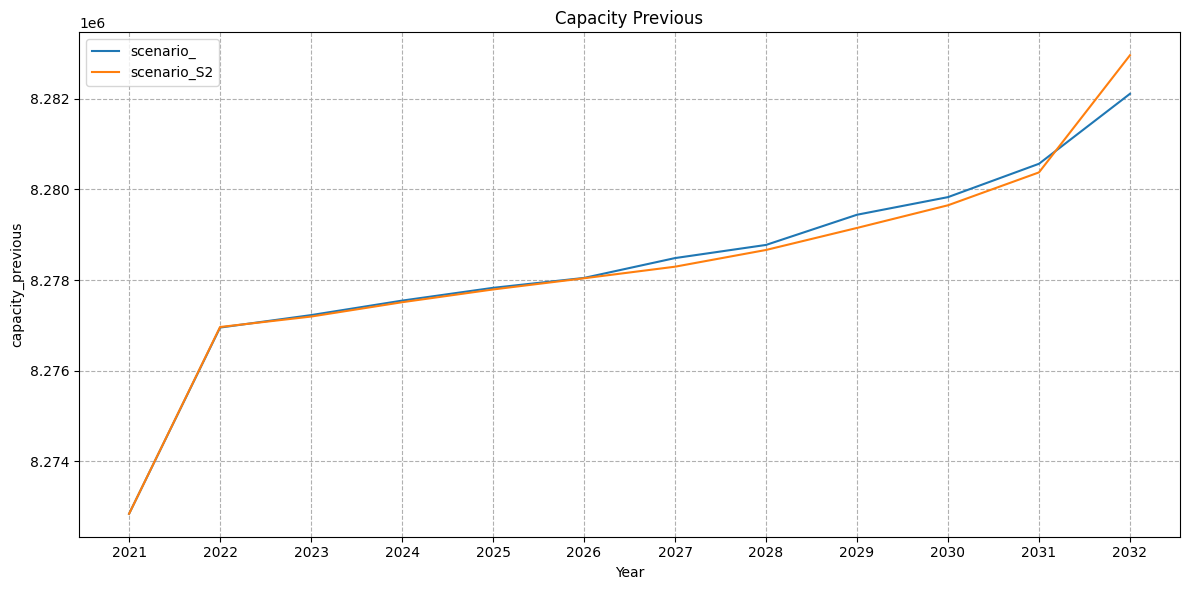

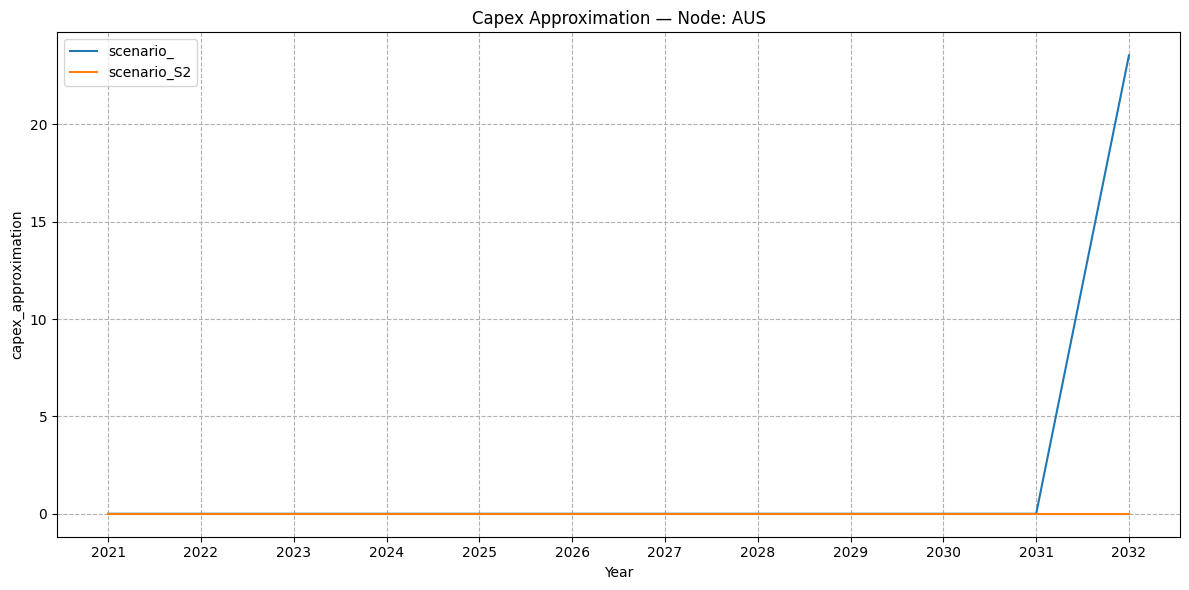

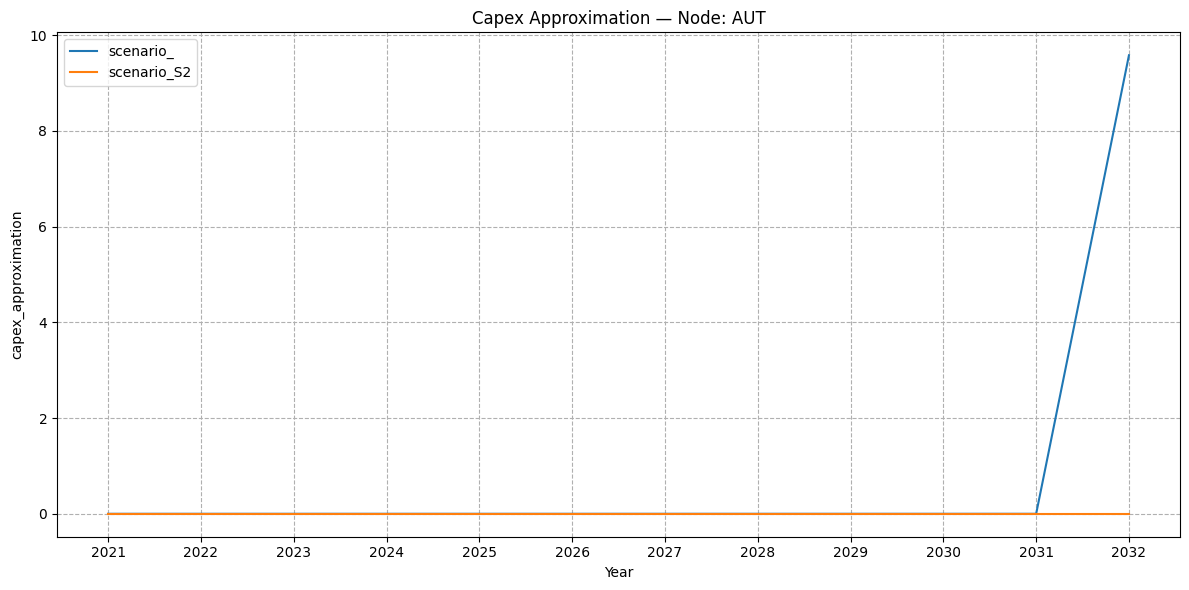

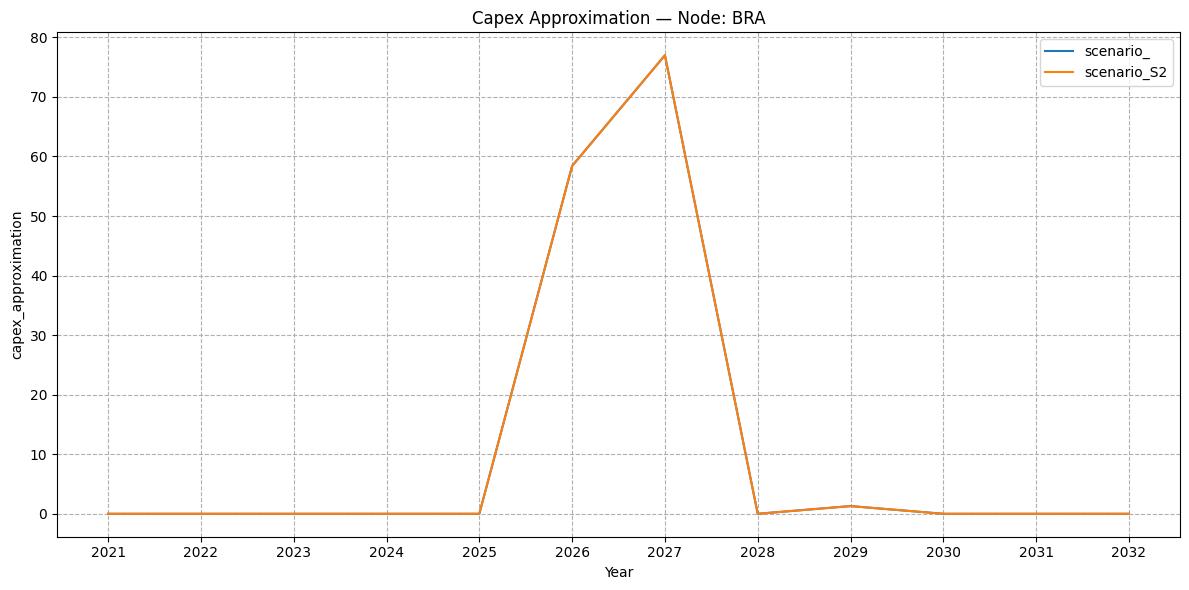

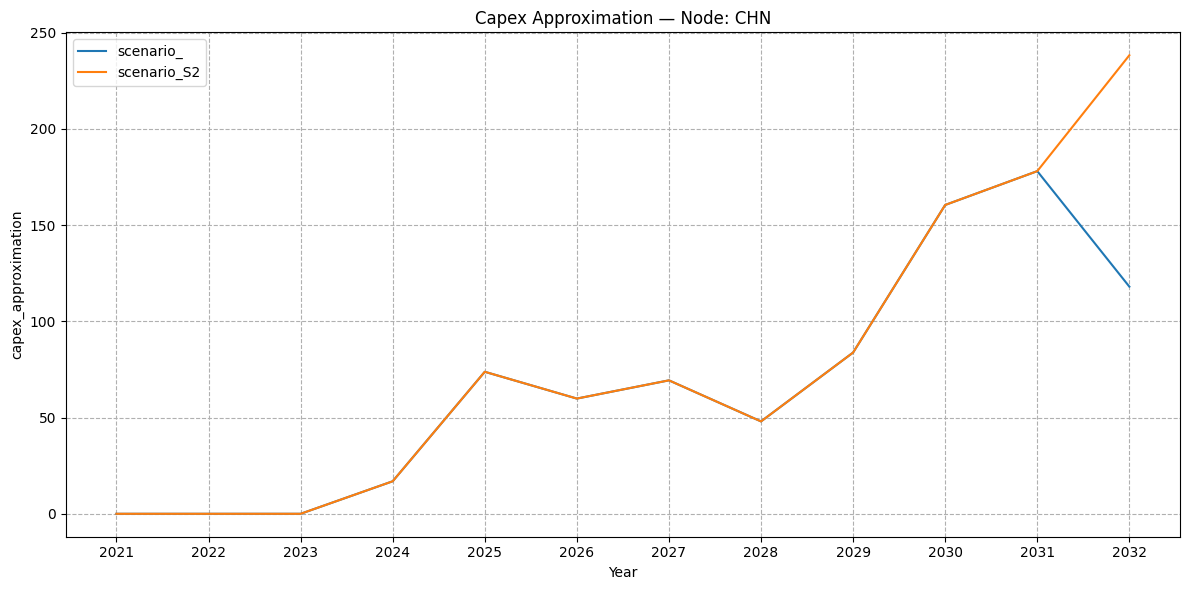

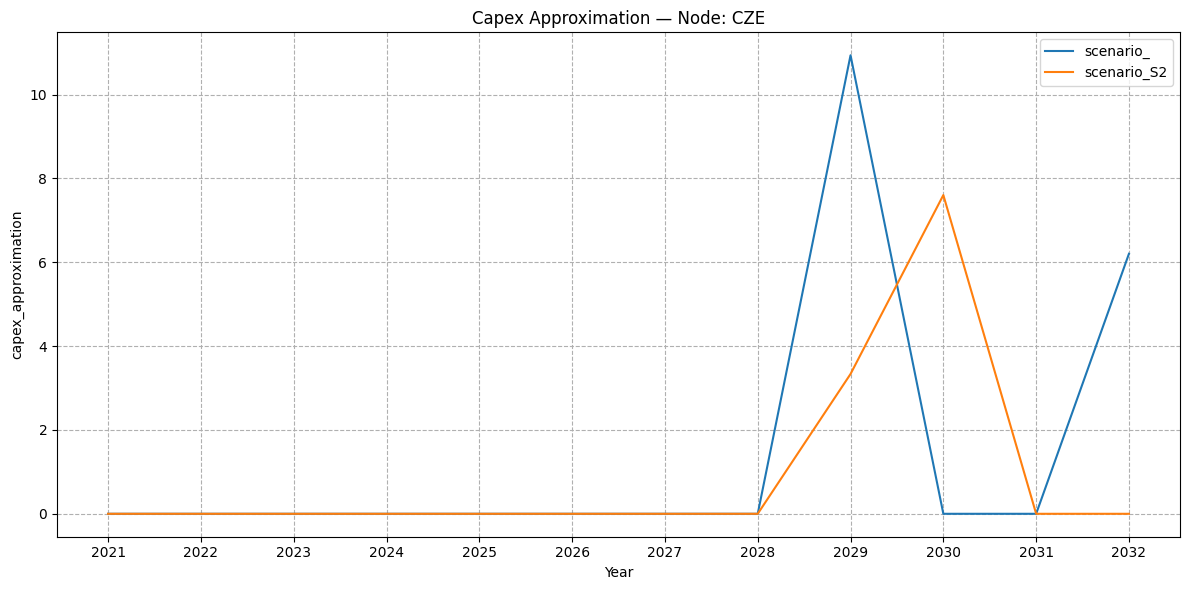

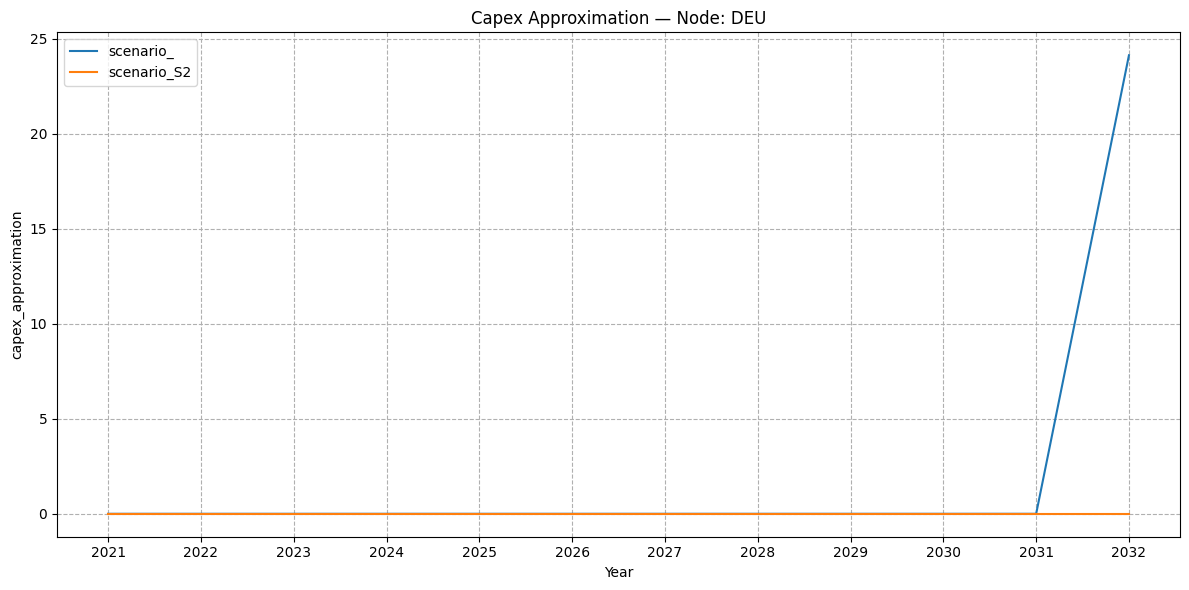

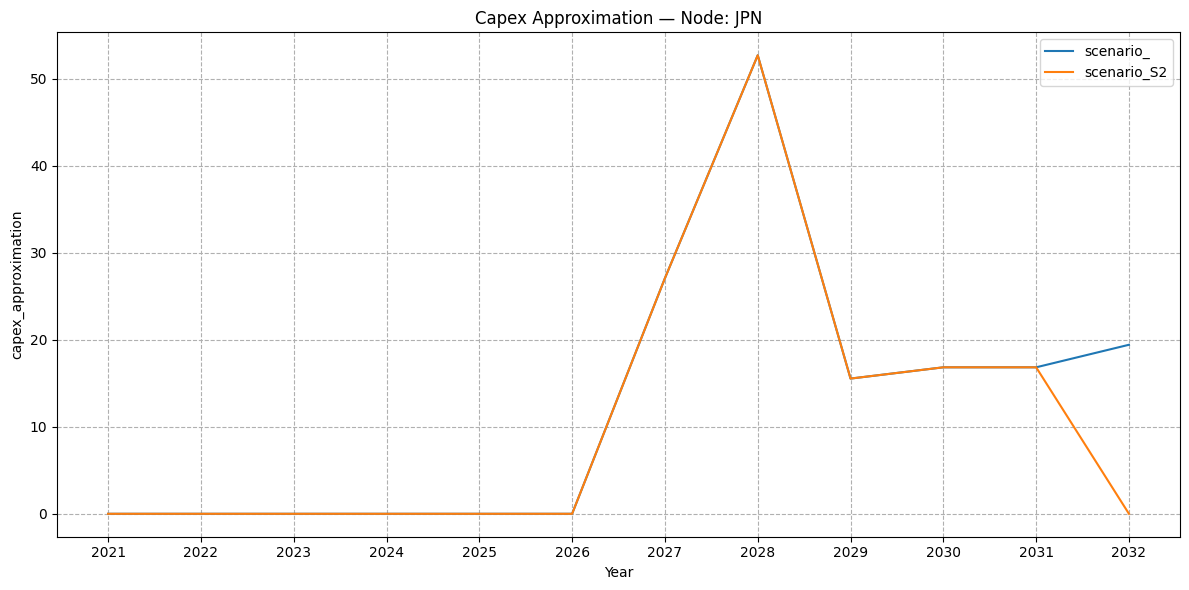

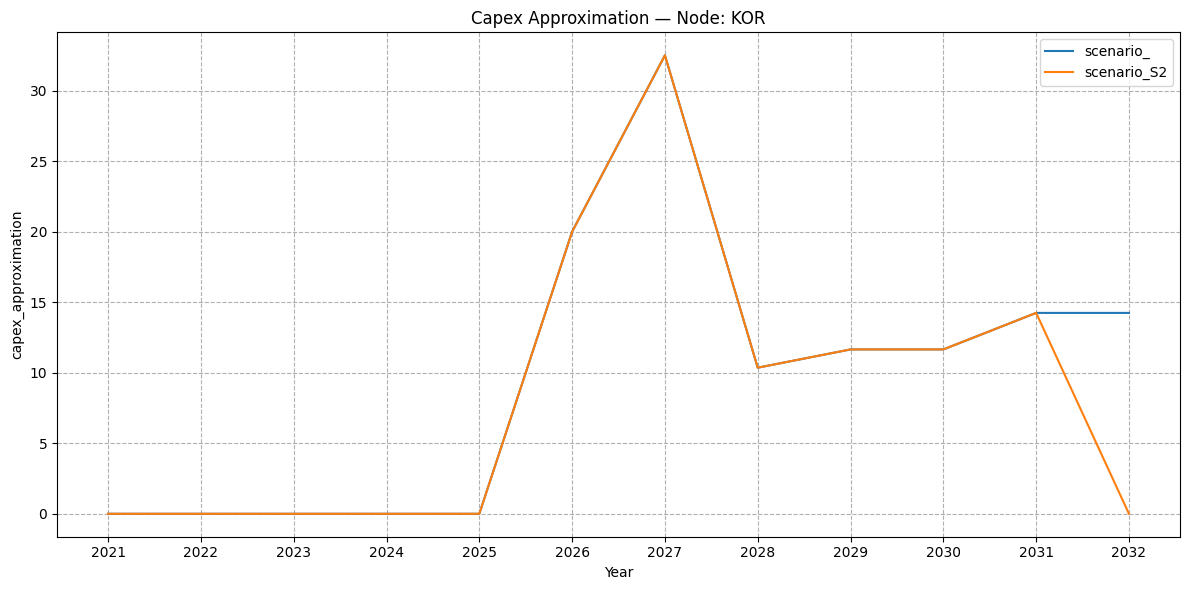

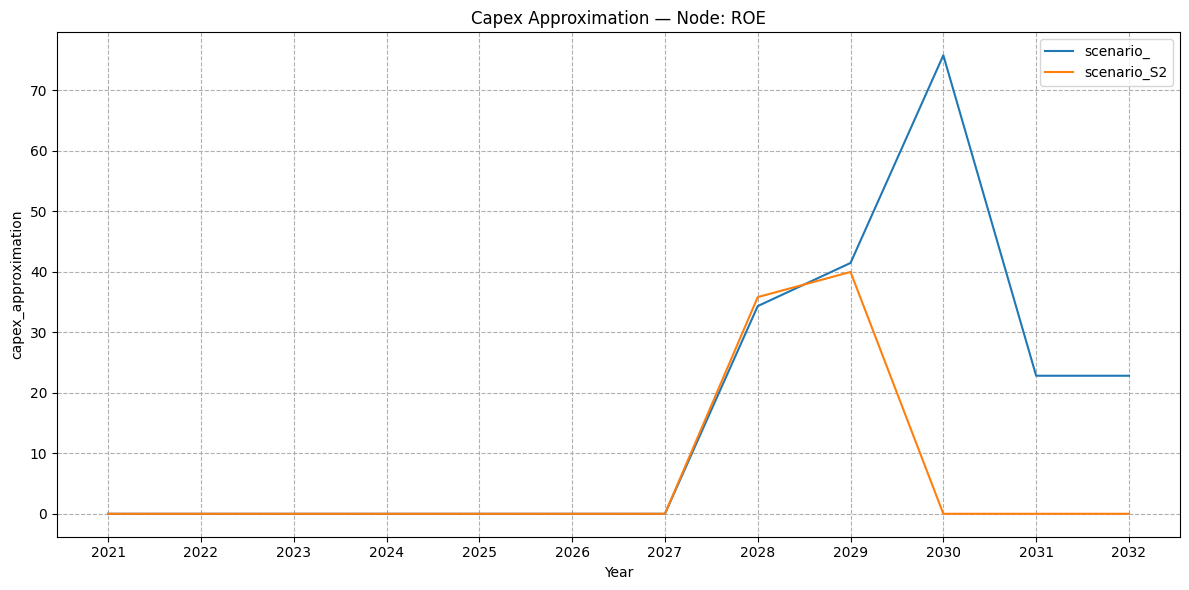

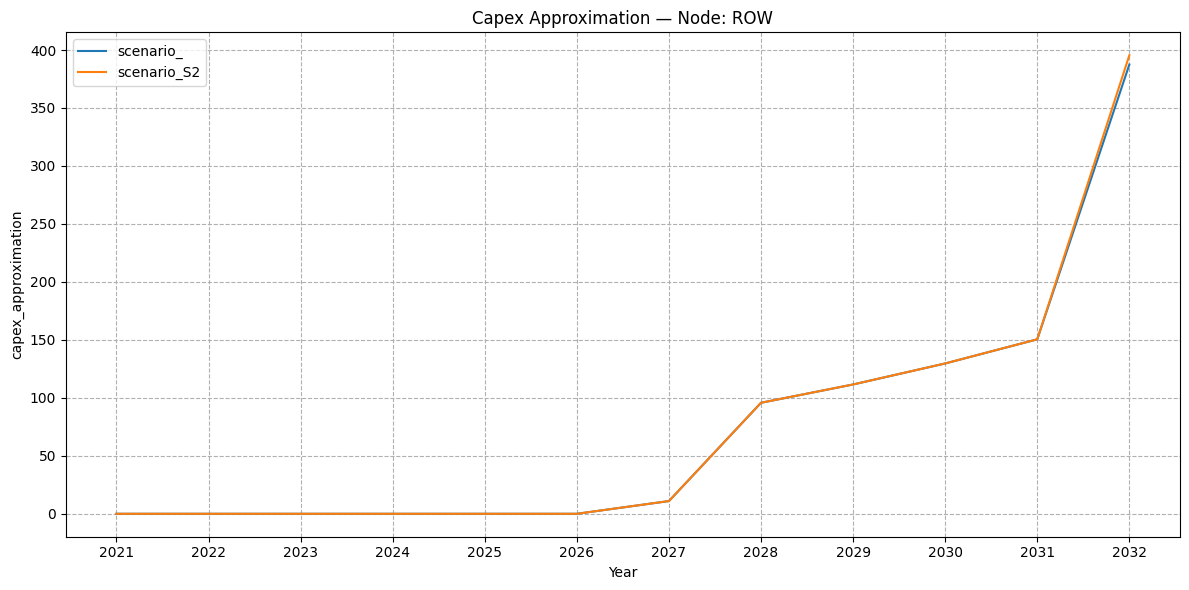

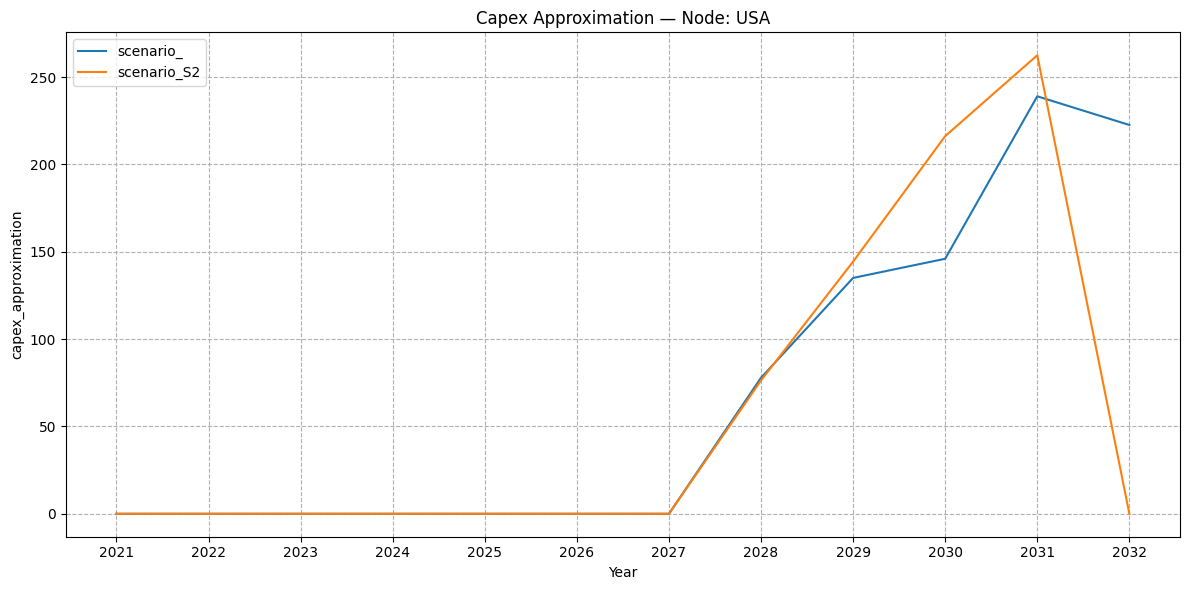

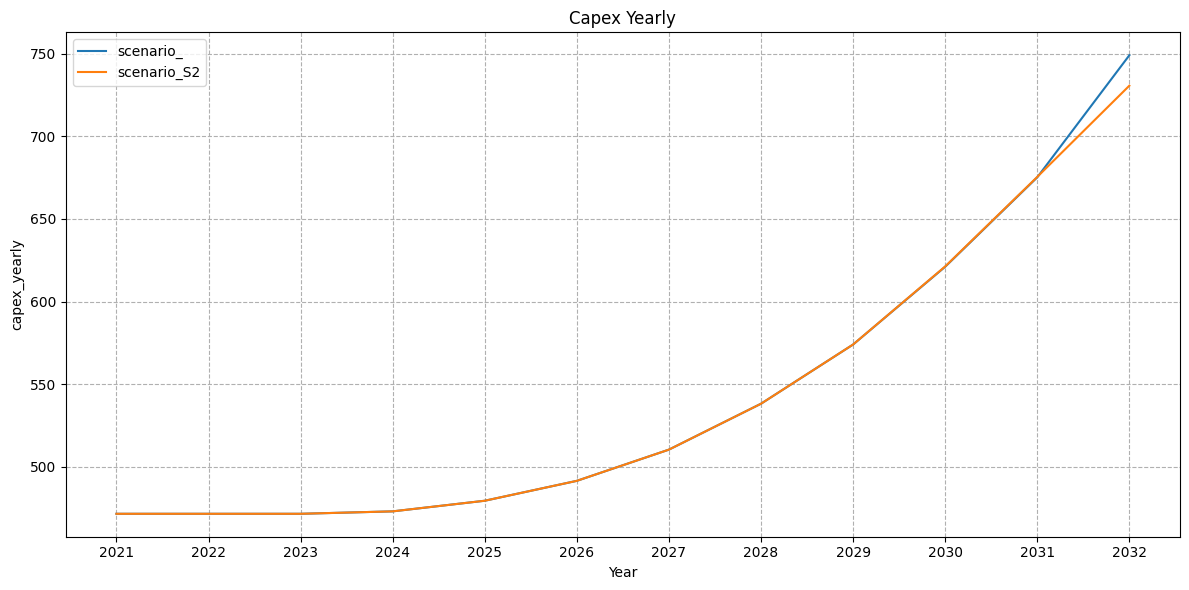

⚠️ Error processing 'carbon_emissions_annual': 'scenario'
⚠️ Error processing 'carbon_emissions_annual_overshoot': 'scenario'
⚠️ Error processing 'carbon_emissions_budget_overshoot': 'scenario'


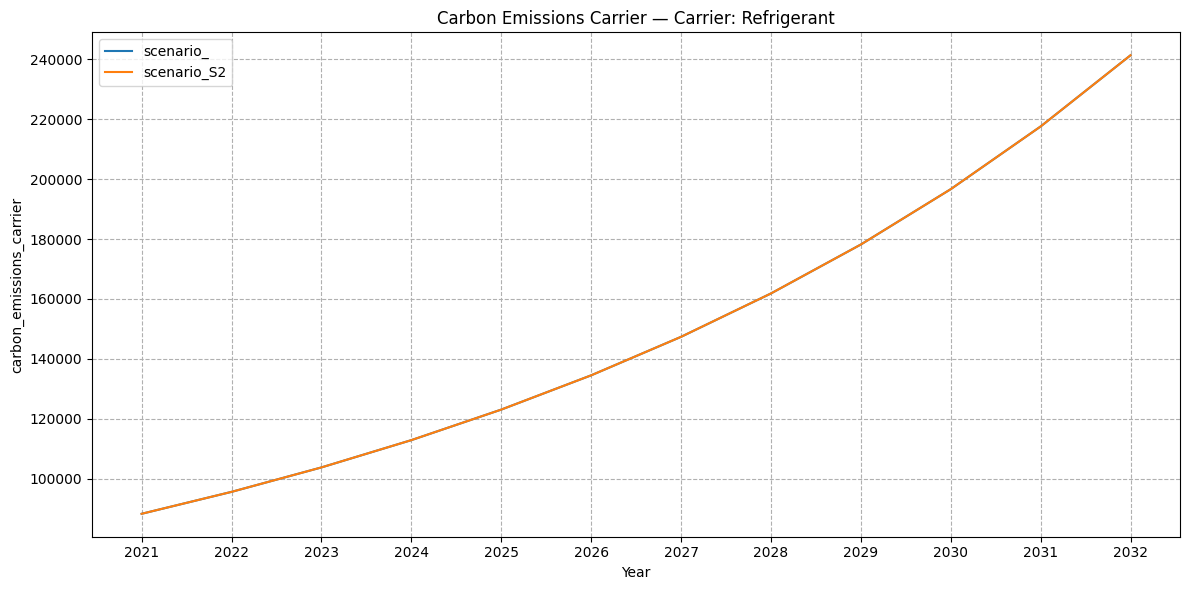

⚠️ Error processing 'carbon_emissions_carrier_total': 'scenario'
⚠️ Error processing 'carbon_emissions_cumulative': 'scenario'


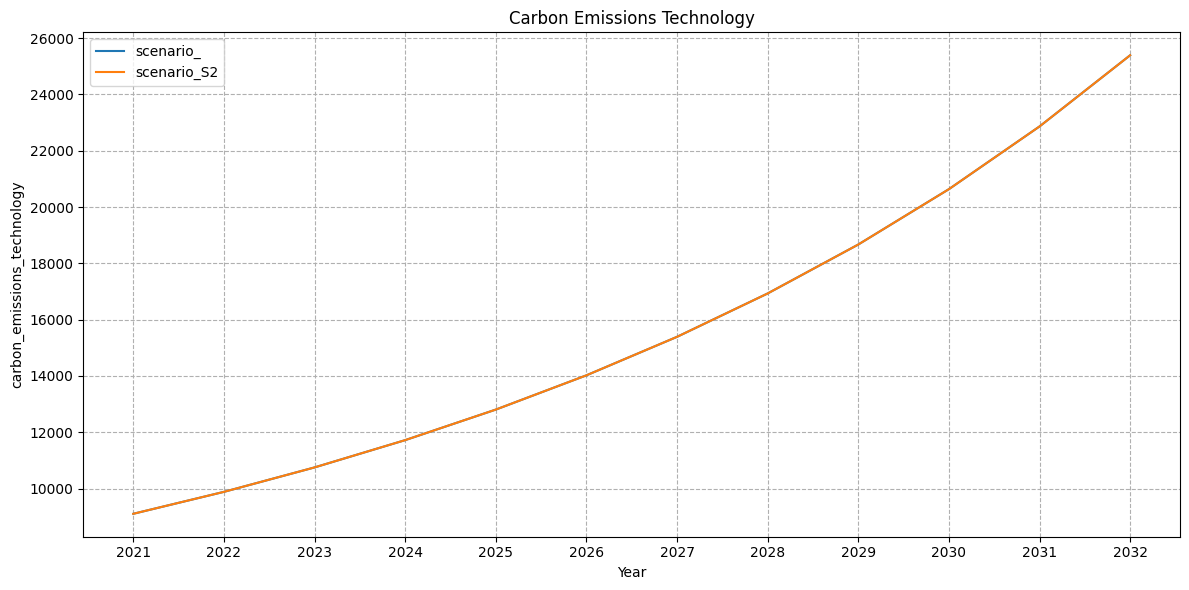

⚠️ Error processing 'carbon_emissions_technology_total': 'scenario'


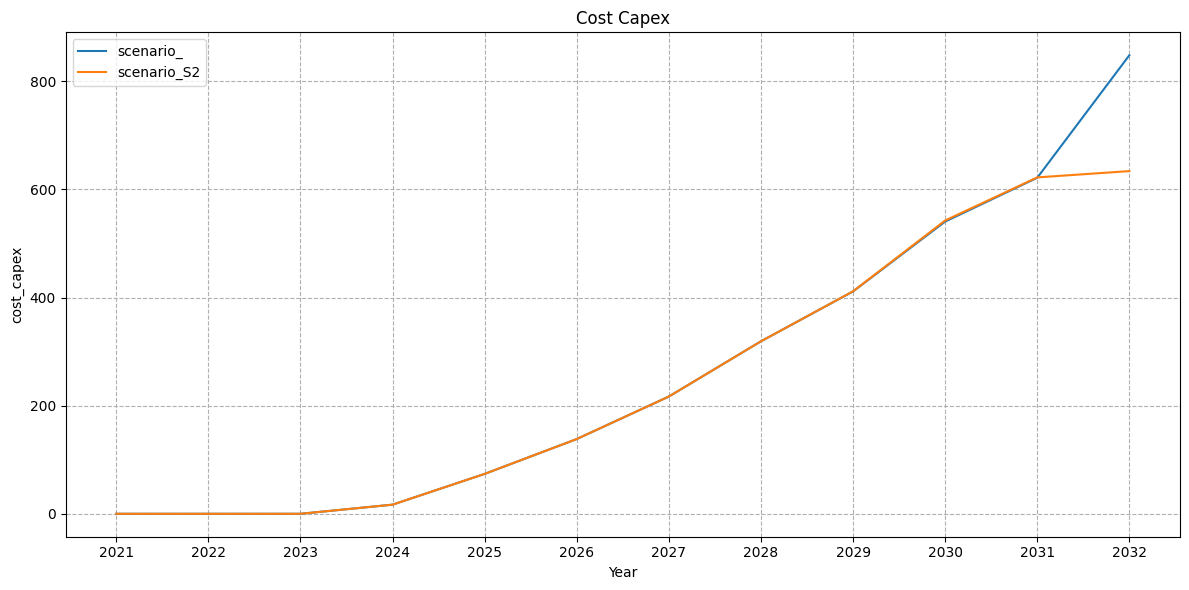

⚠️ Error processing 'cost_capex_total': 'scenario'
⚠️ Error processing 'cost_carbon_emissions_total': 'scenario'


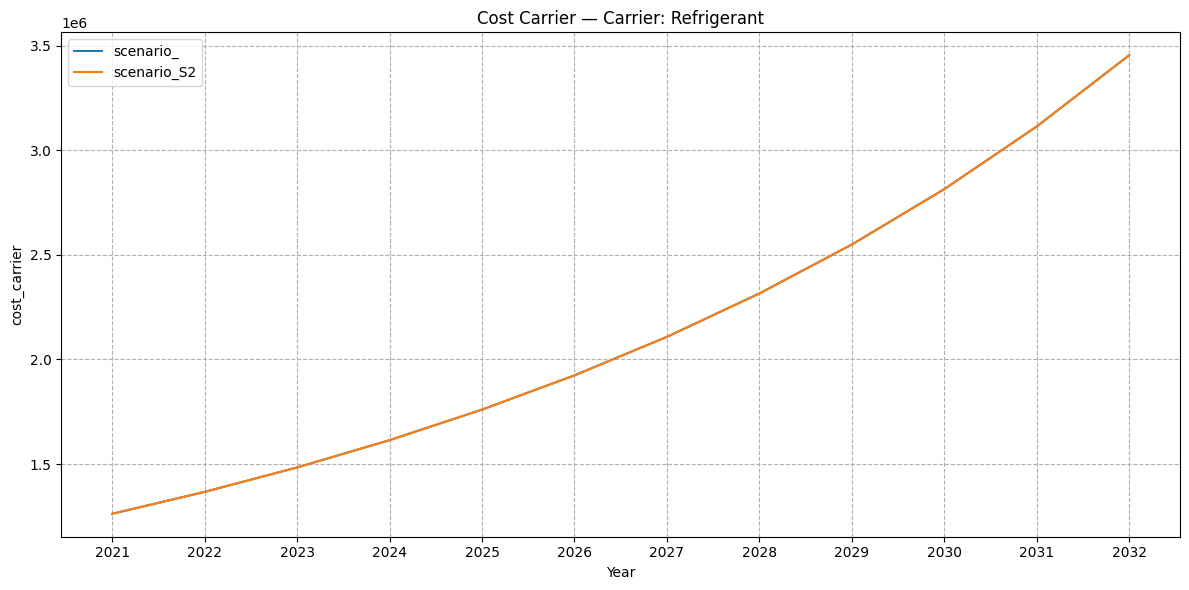

⚠️ Error processing 'cost_carrier_total': 'scenario'


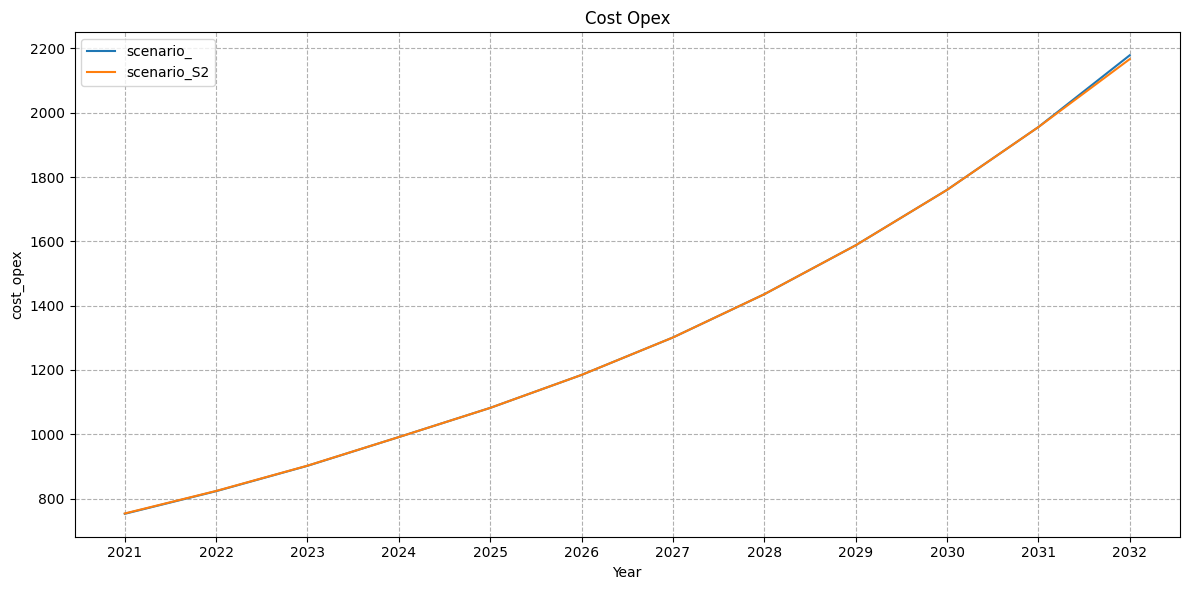

⚠️ Error processing 'cost_opex_total': 'scenario'


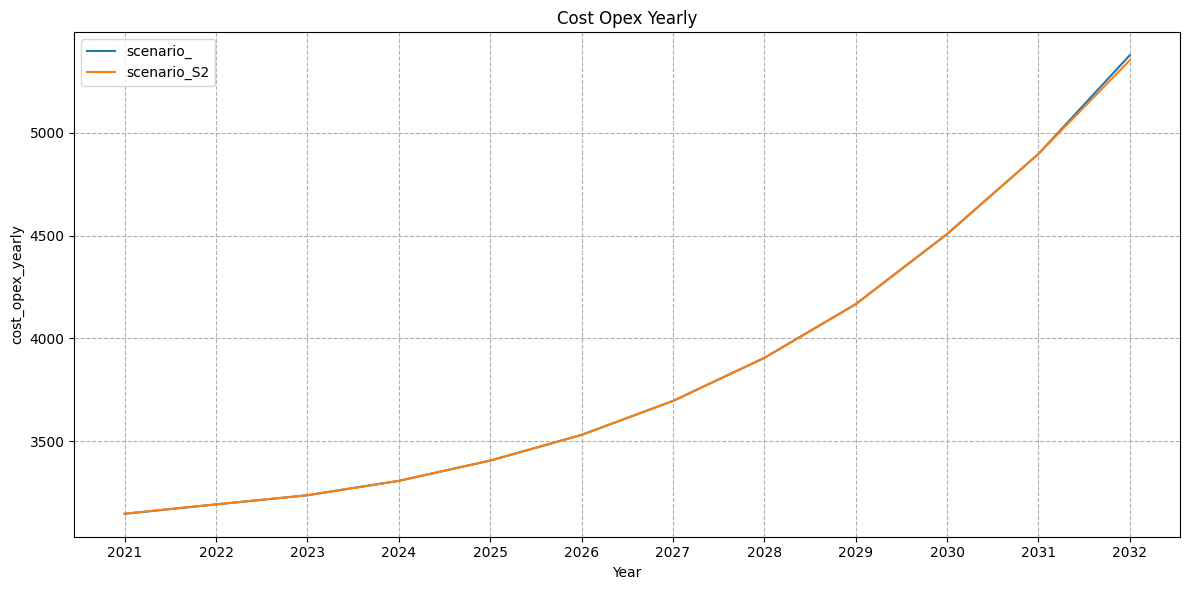

⚠️ Error processing 'cost_total': 'scenario'


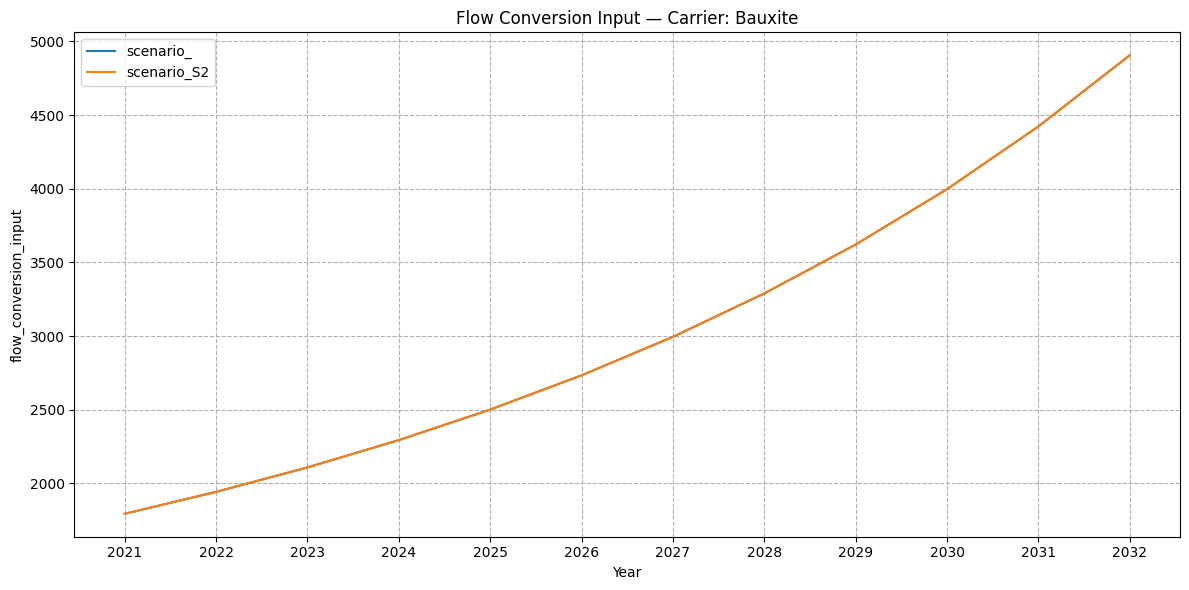

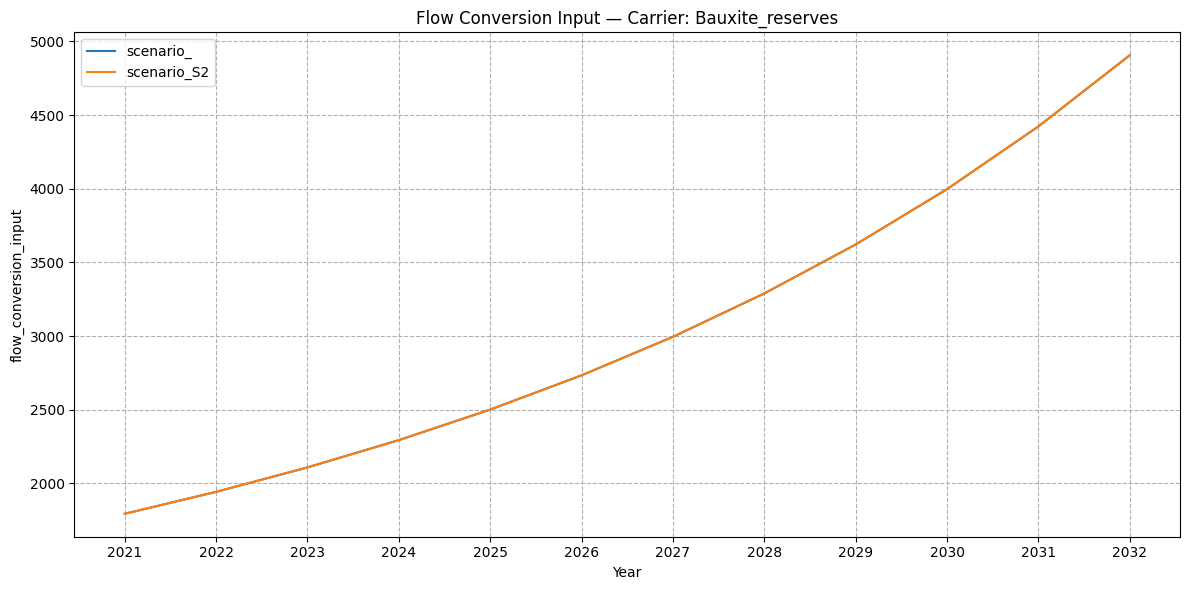

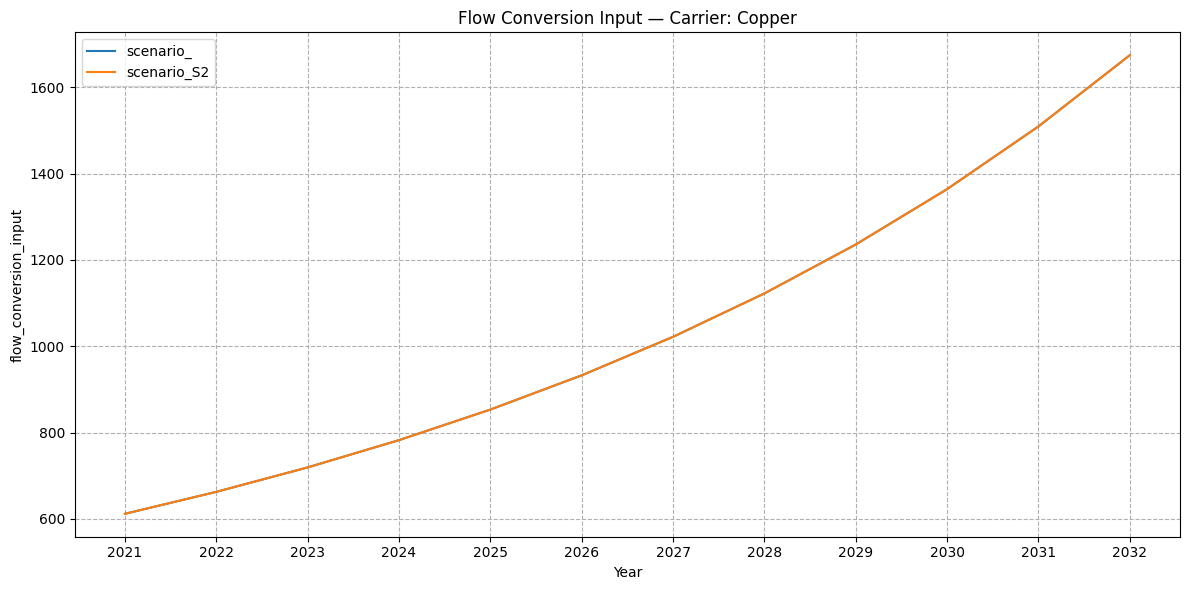

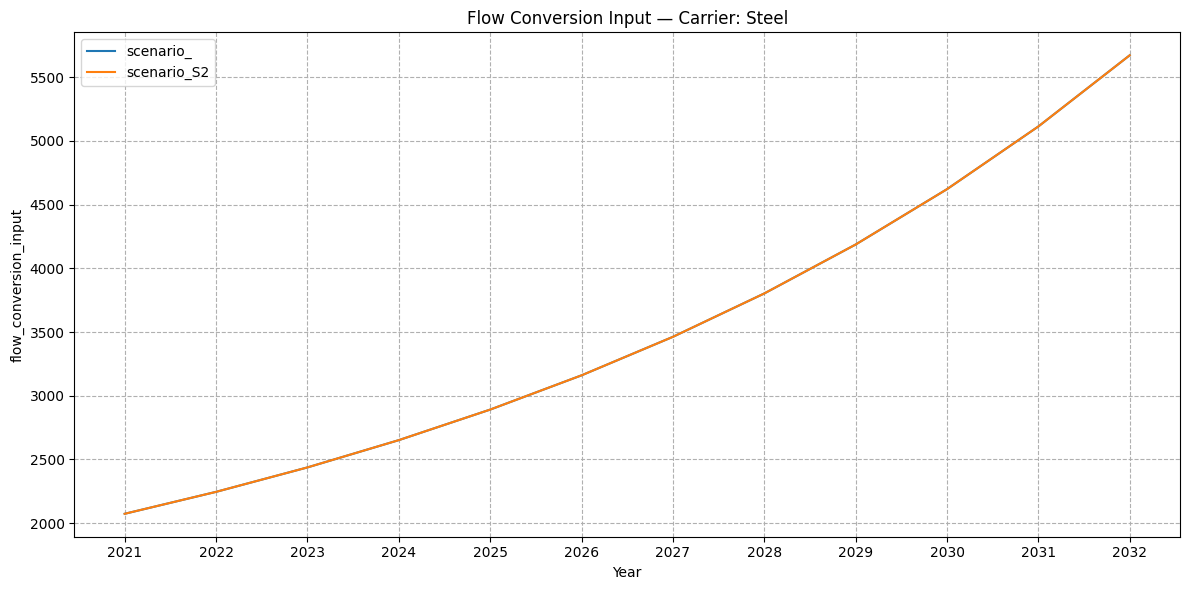

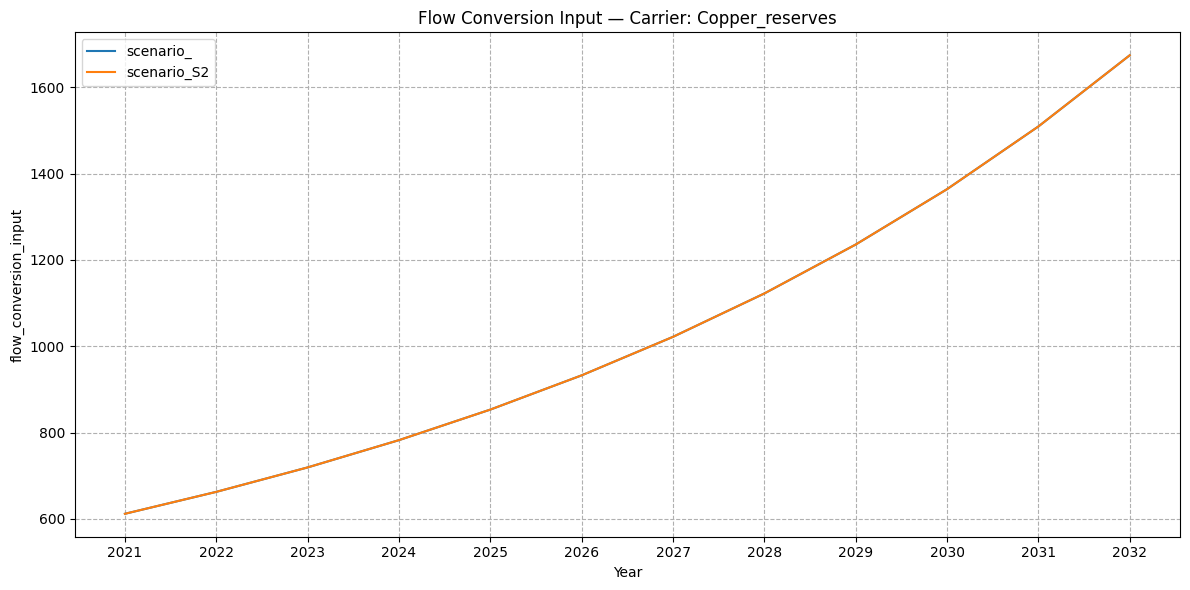

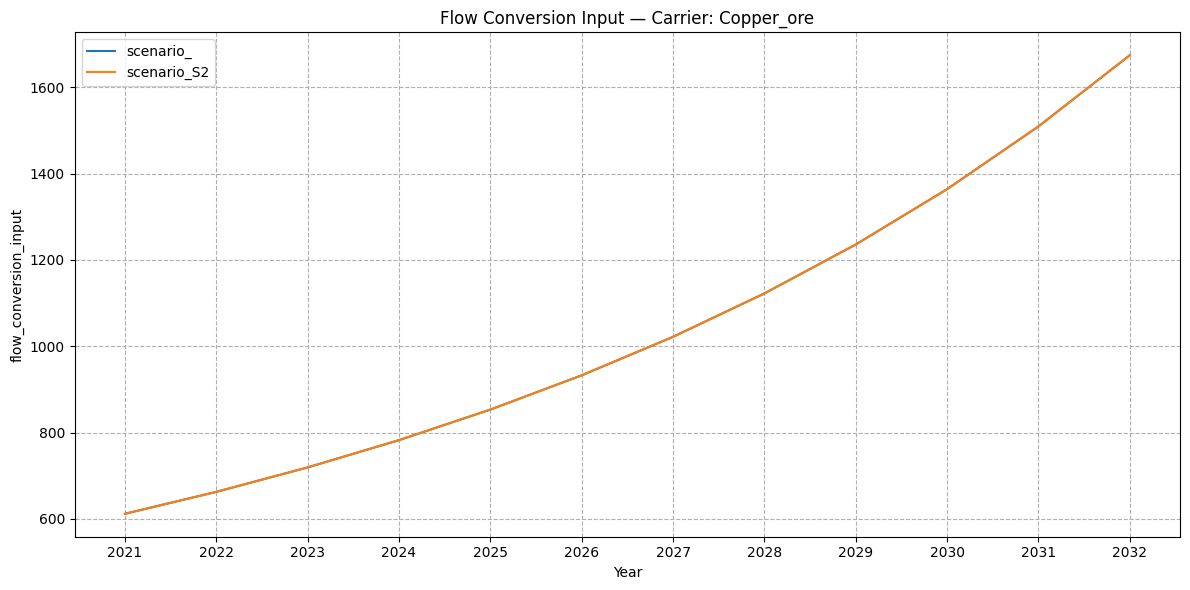

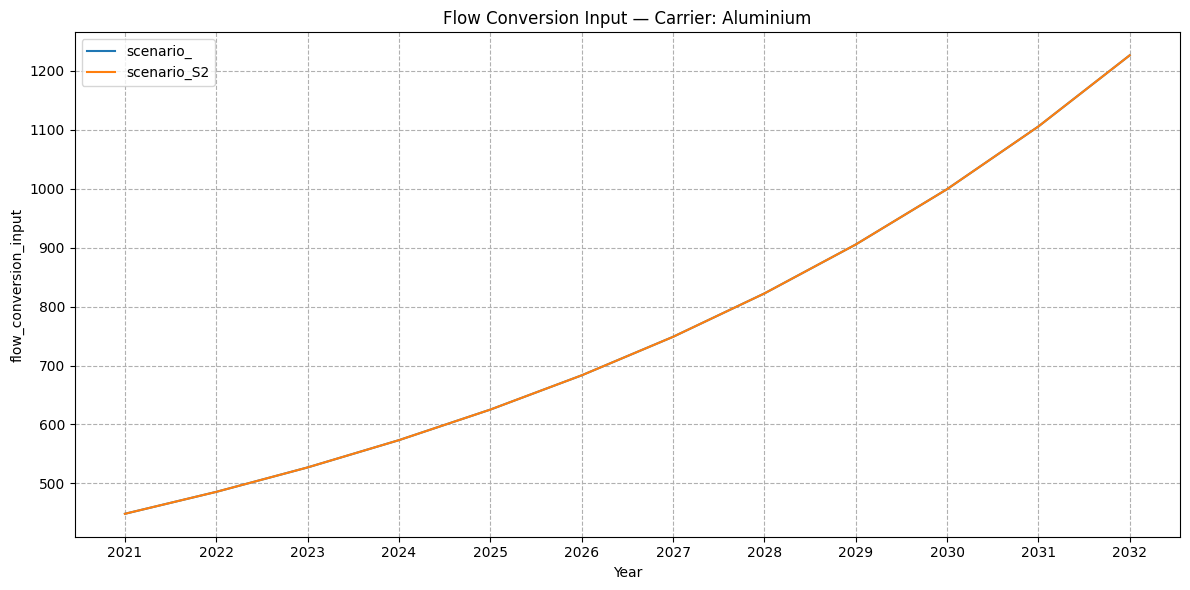

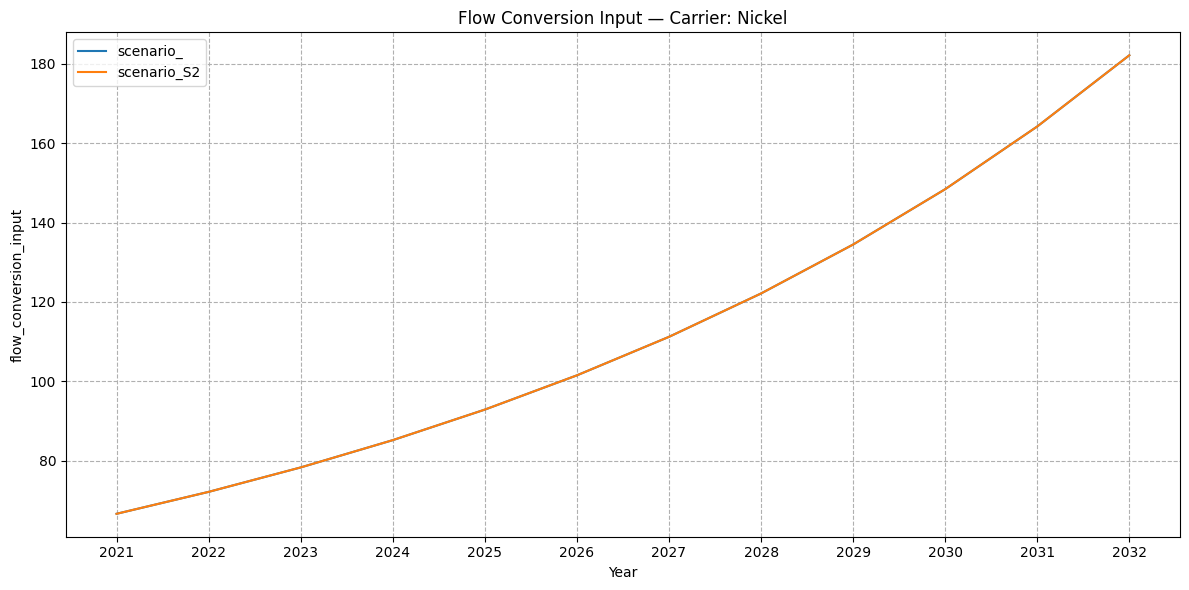

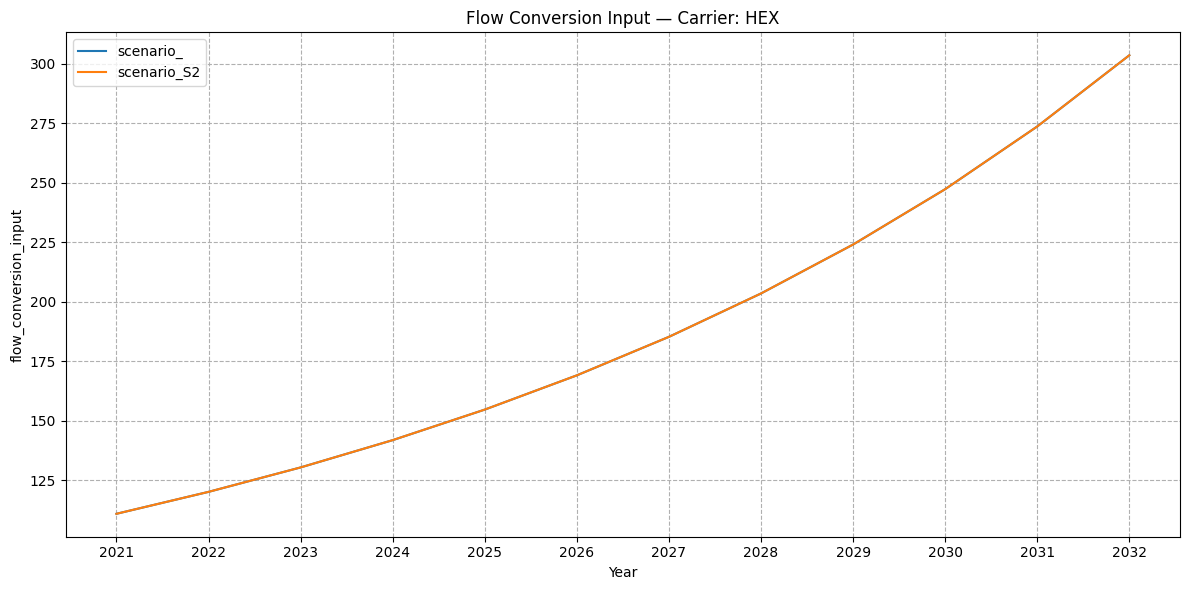

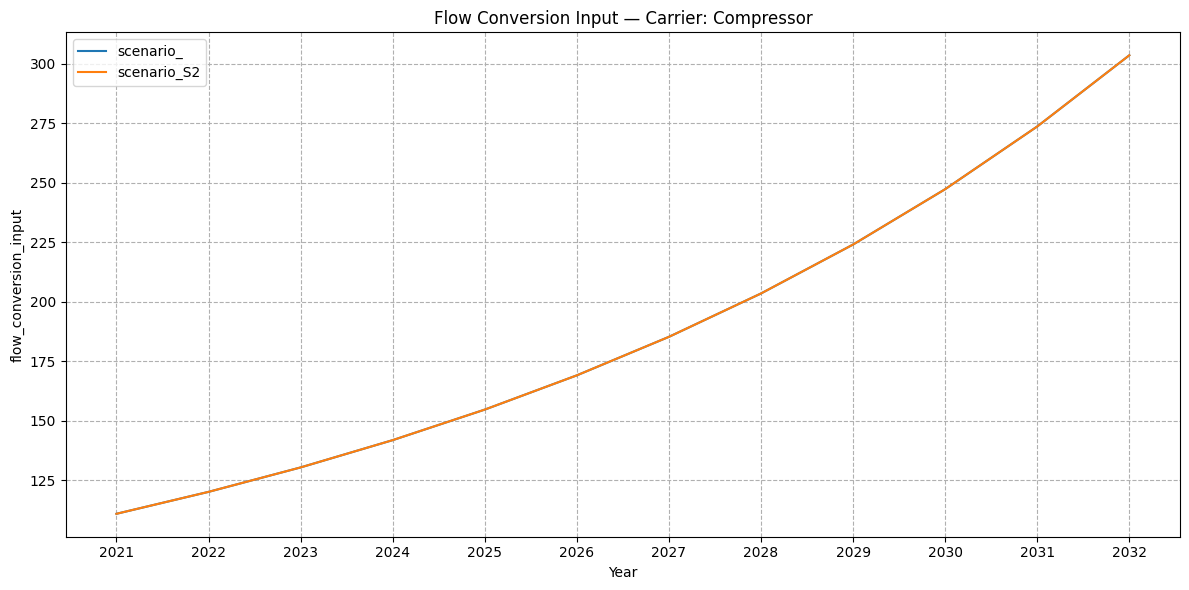

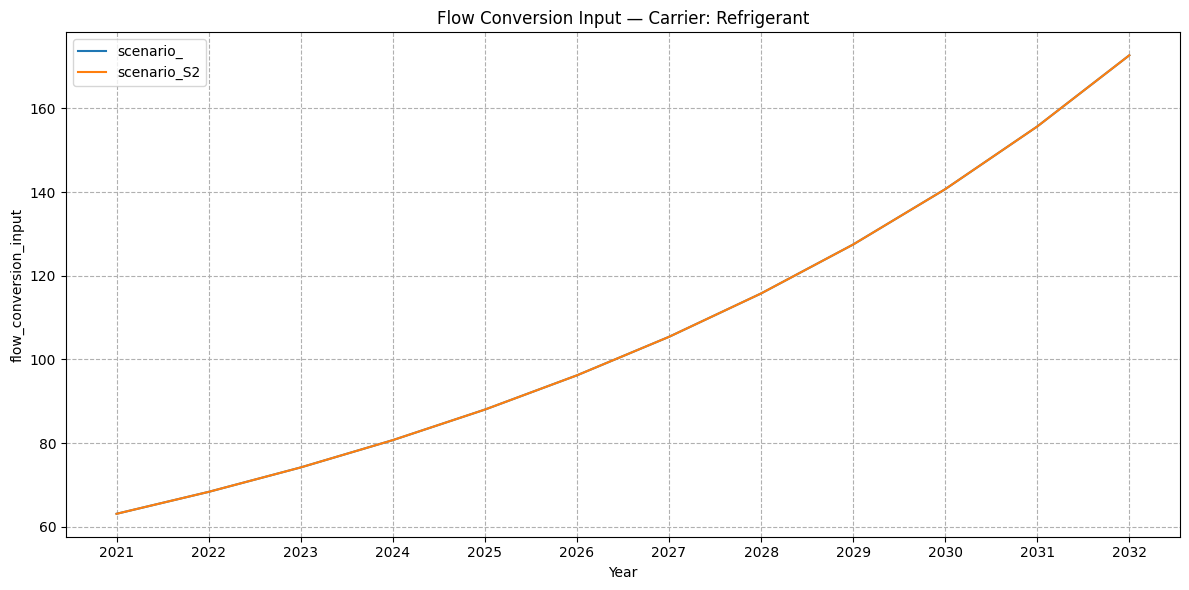

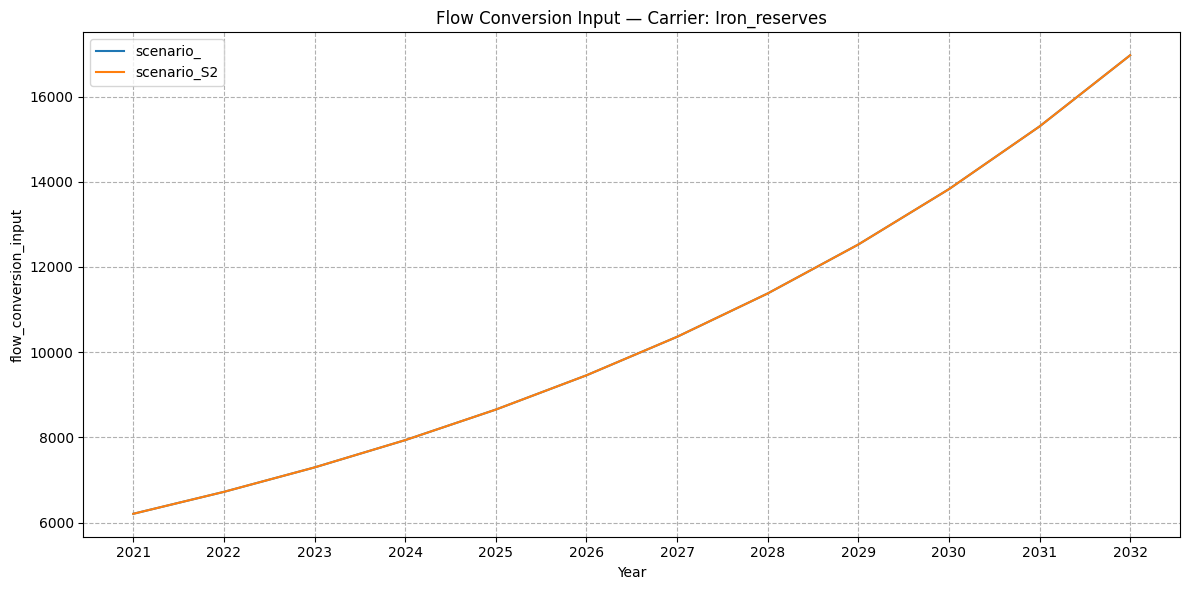

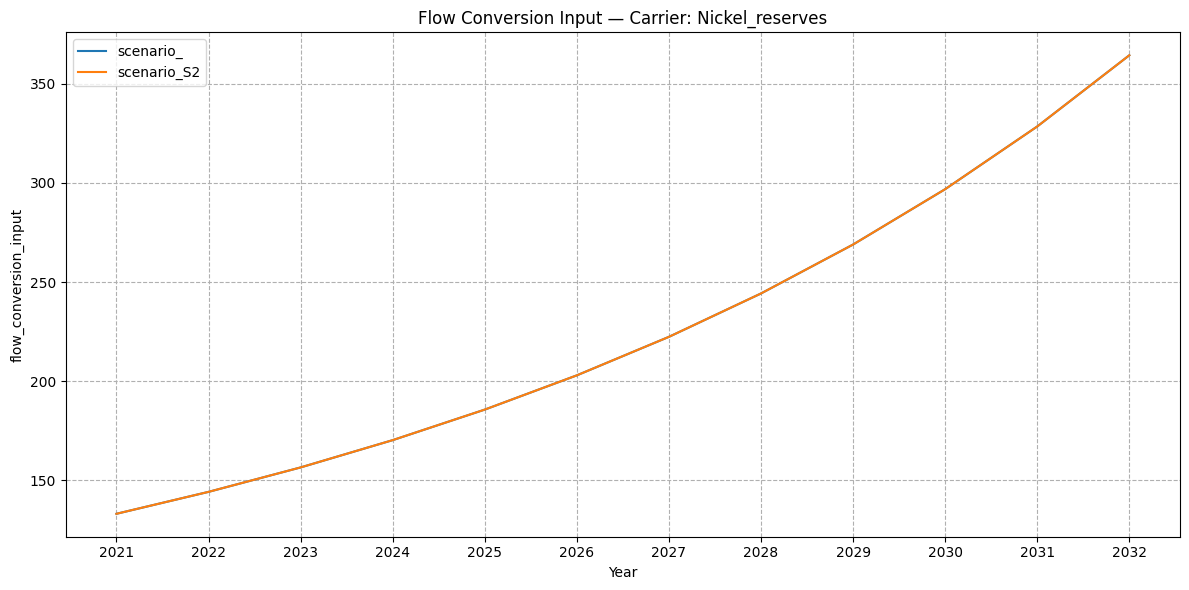

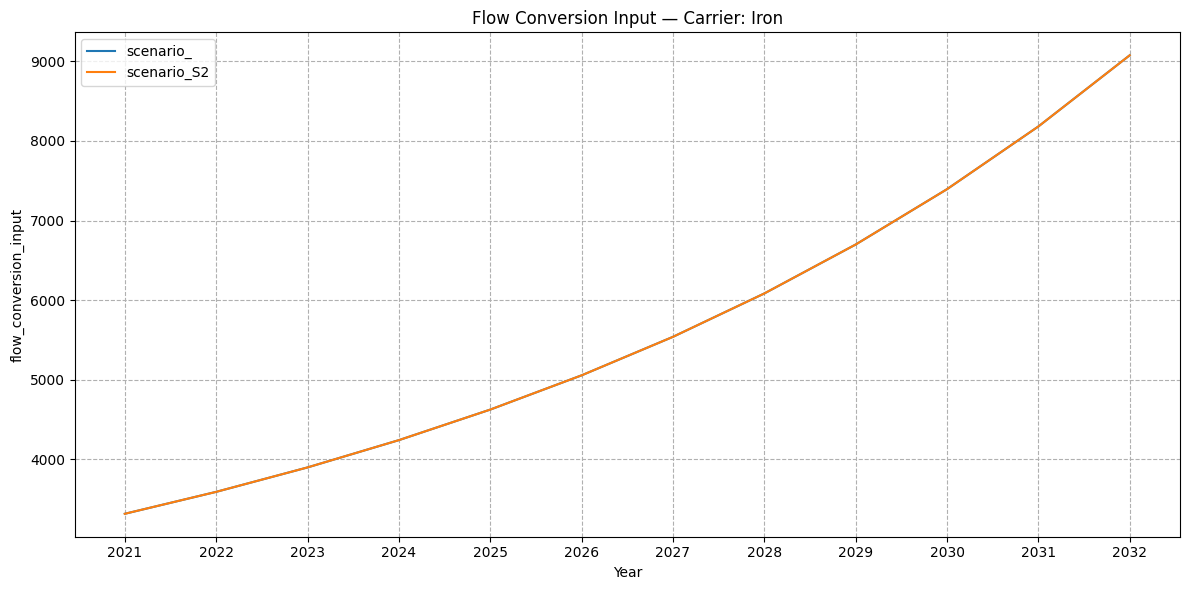

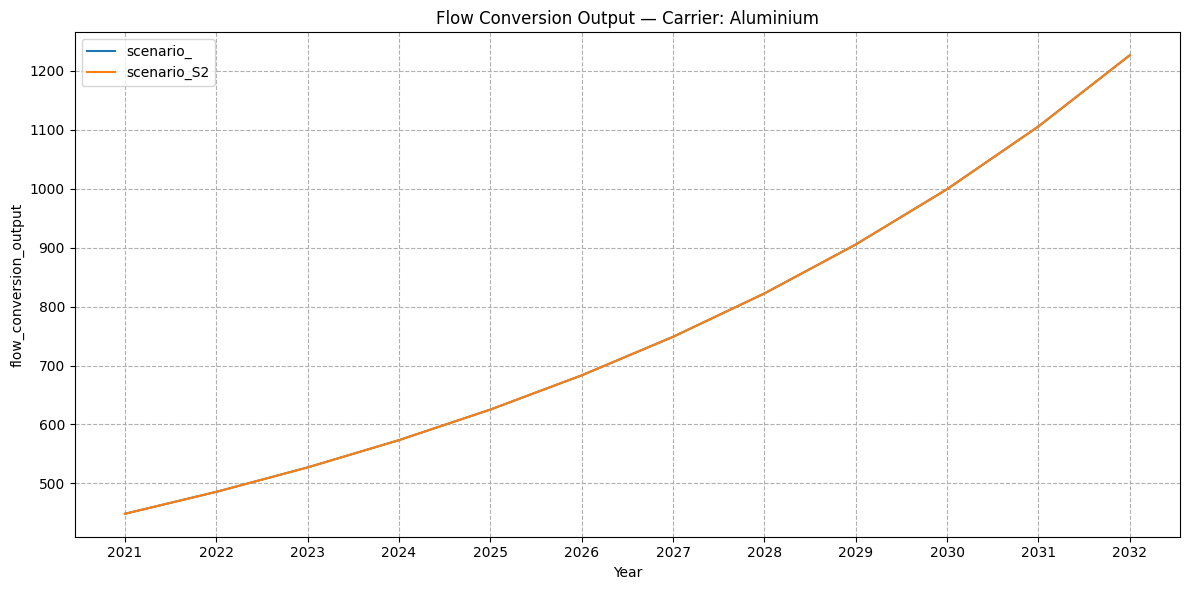

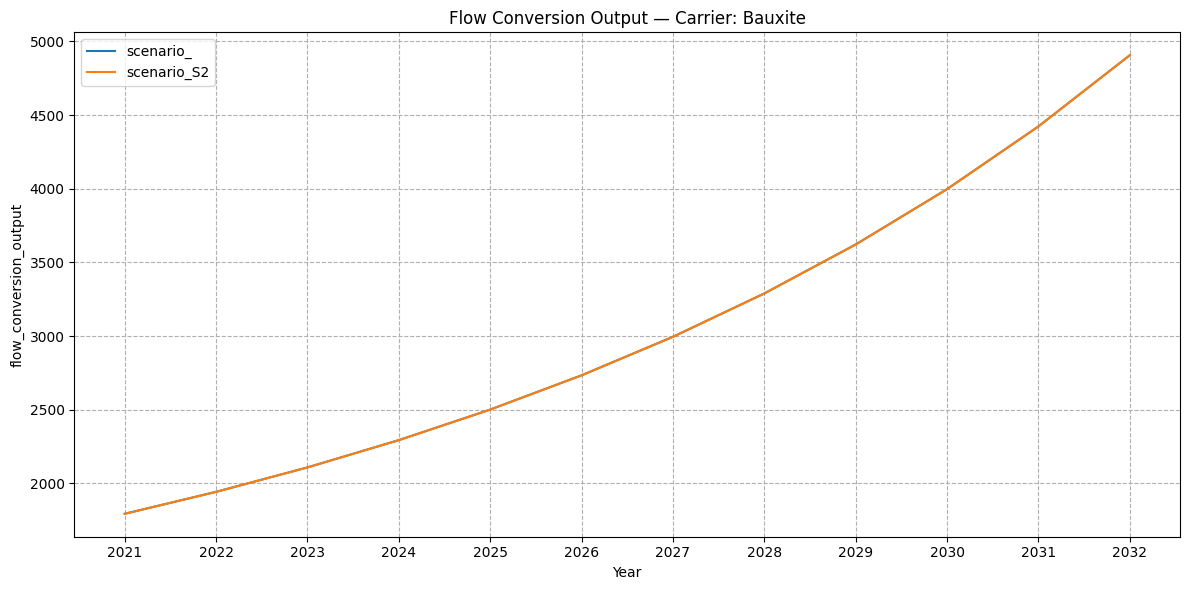

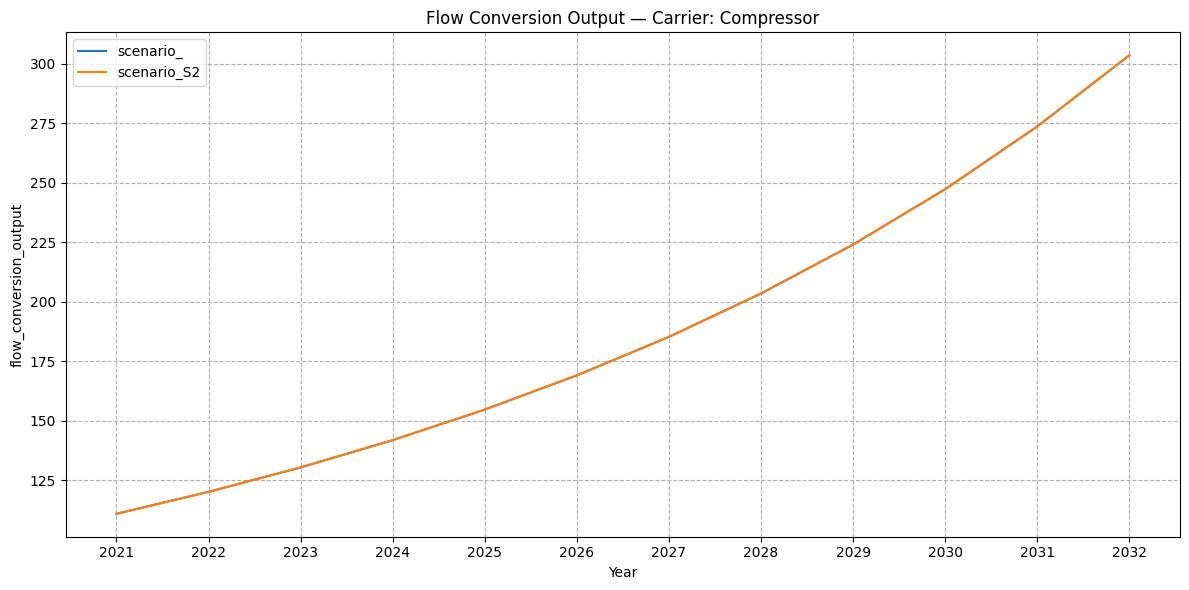

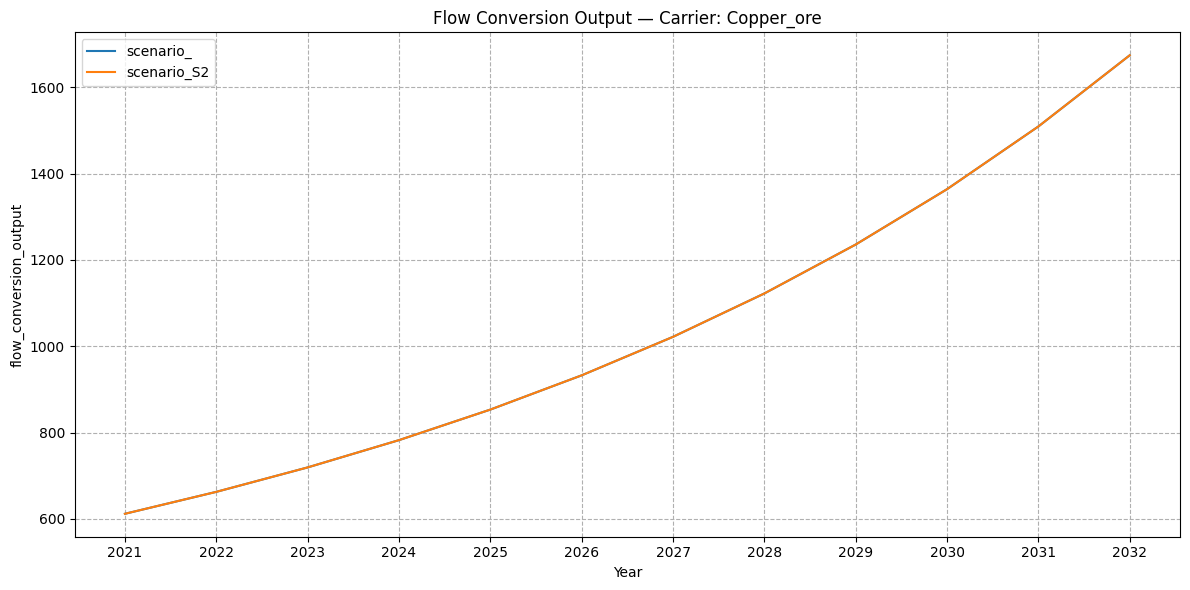

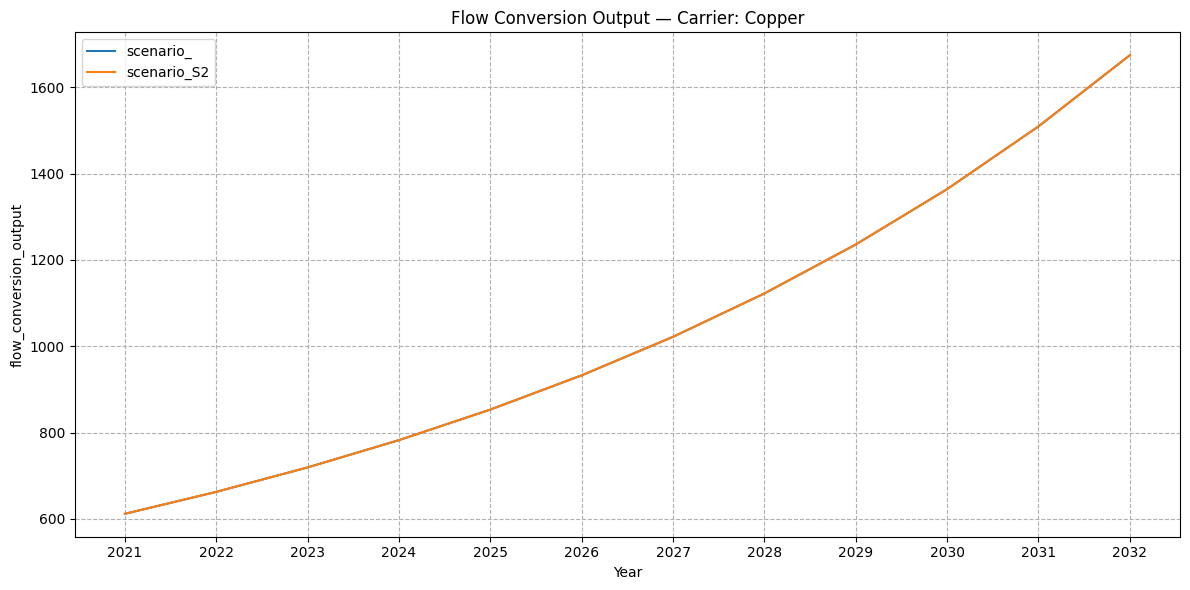

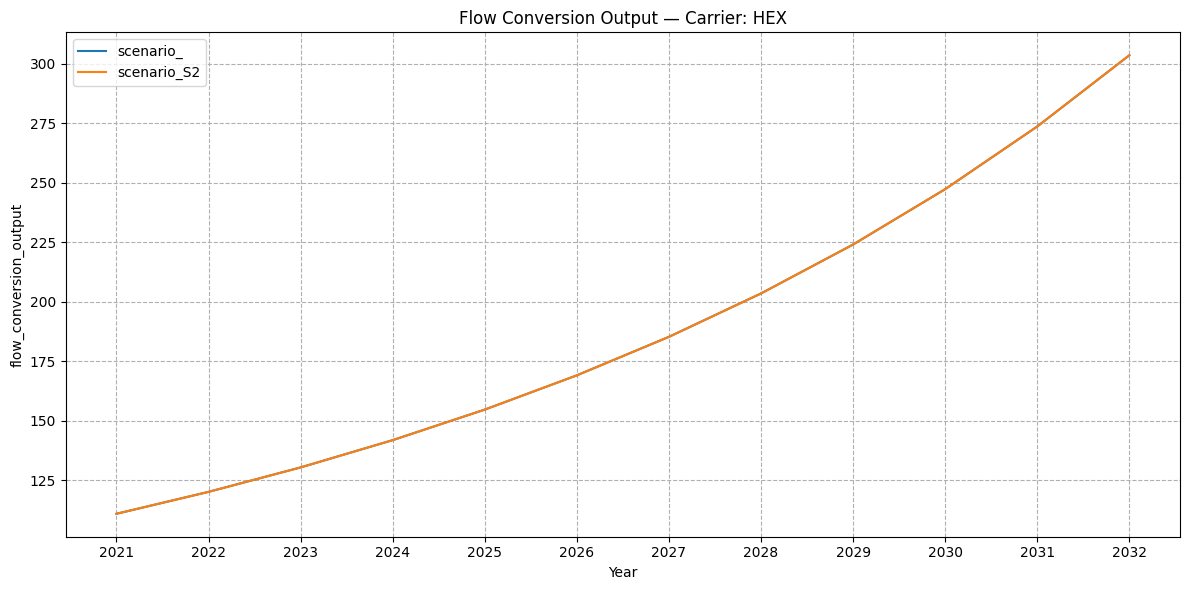

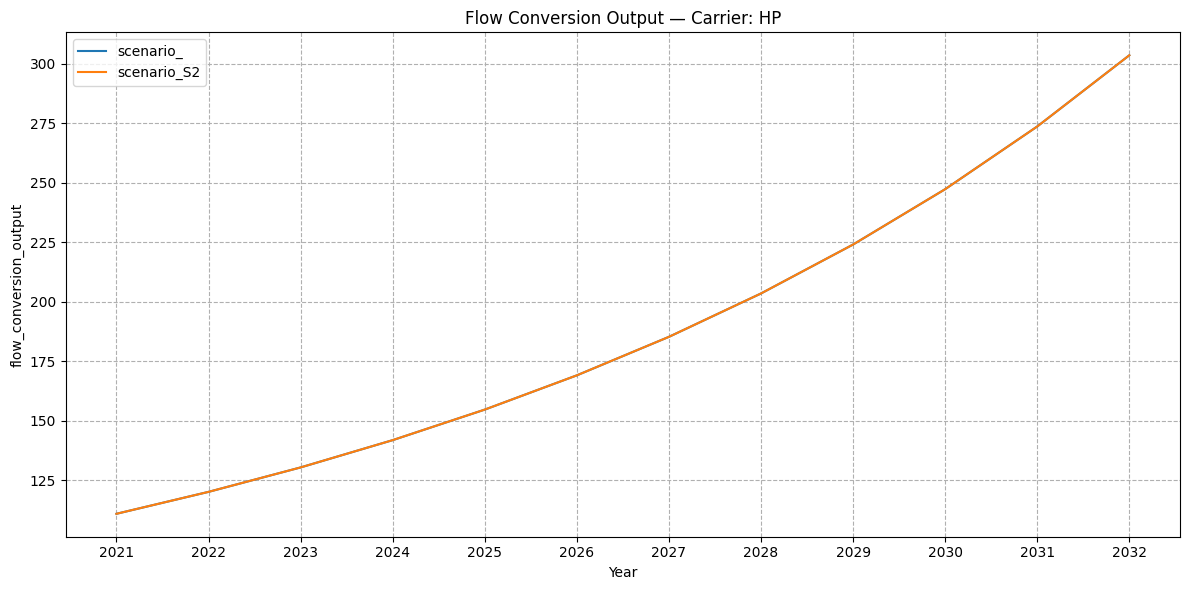

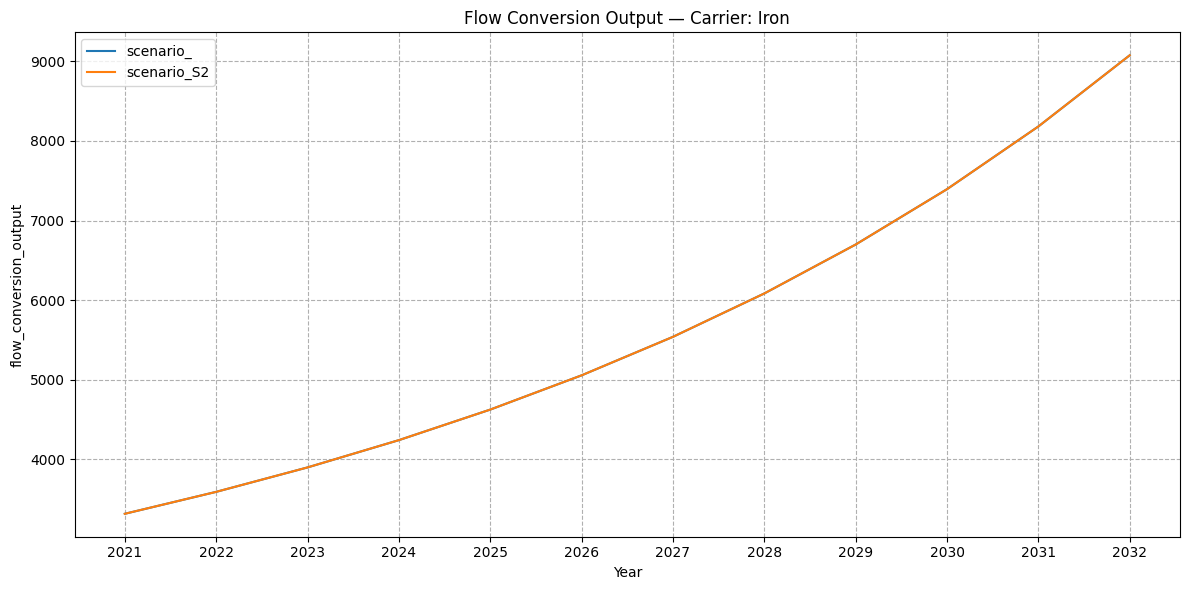

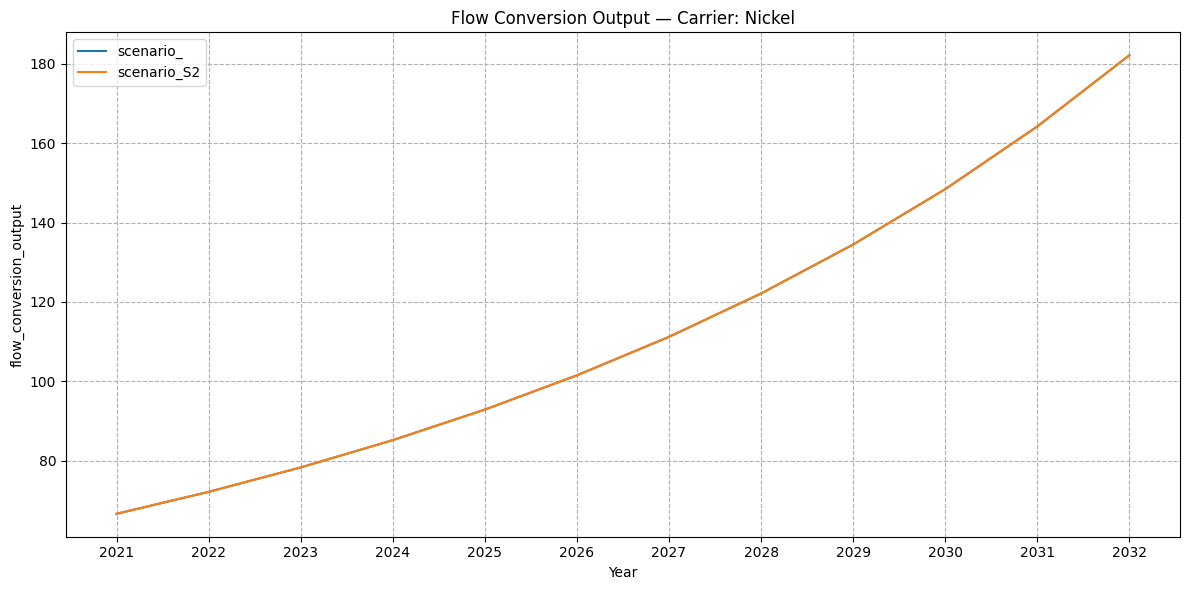

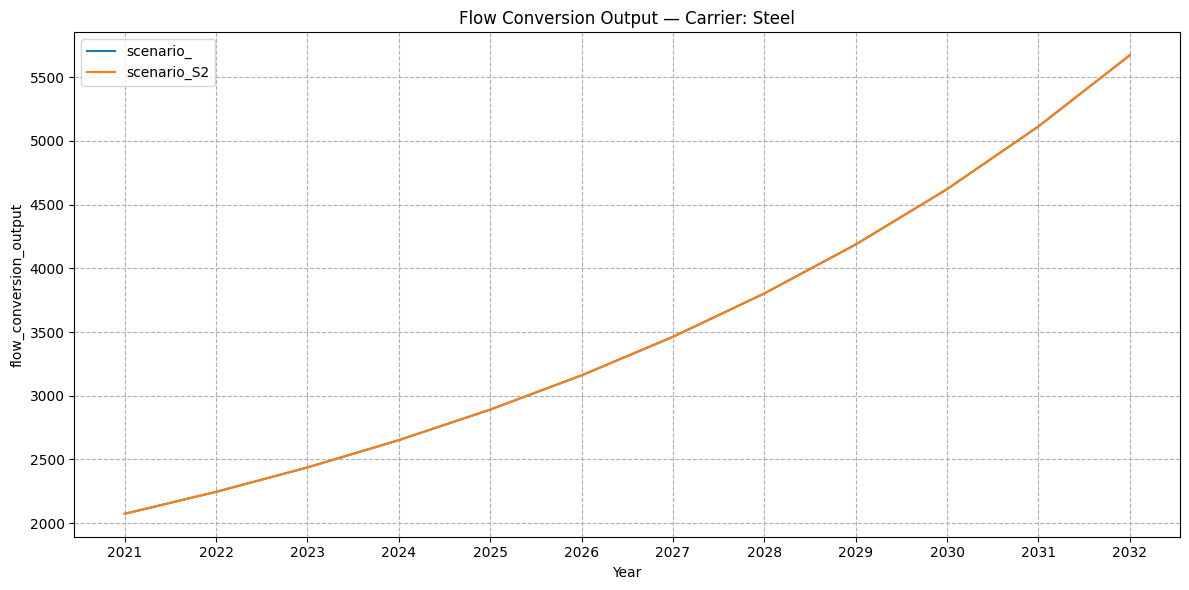

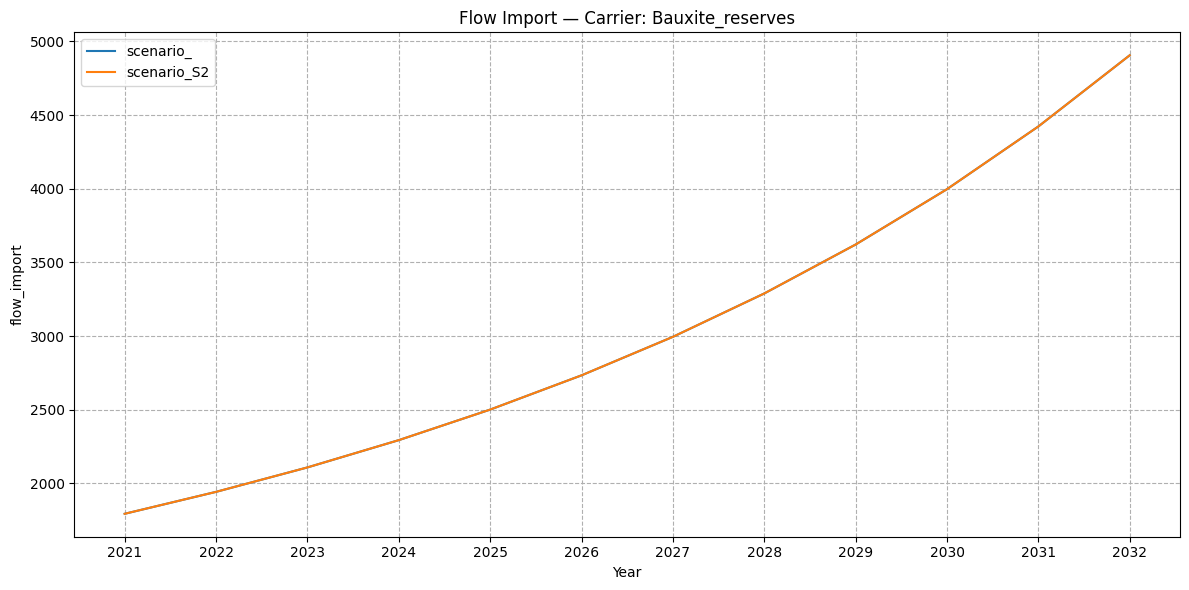

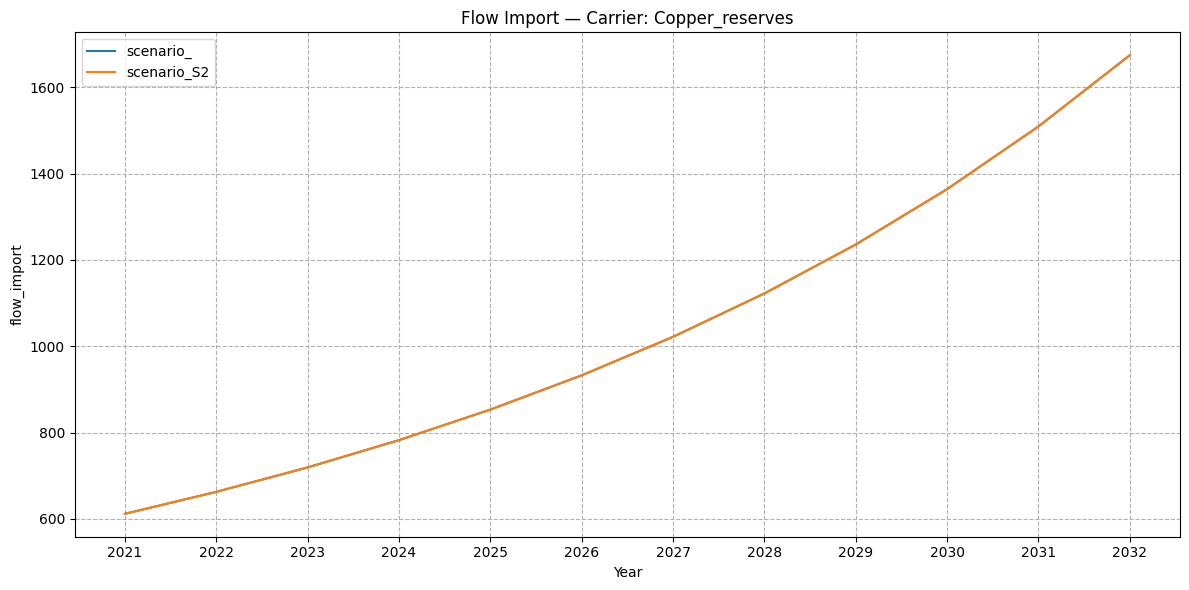

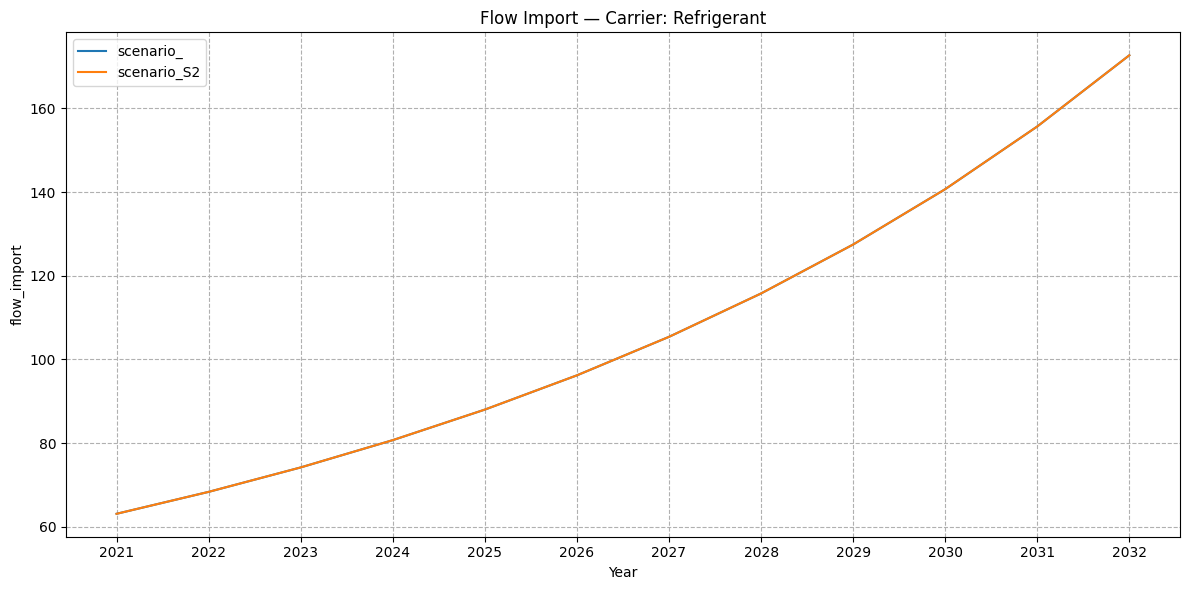

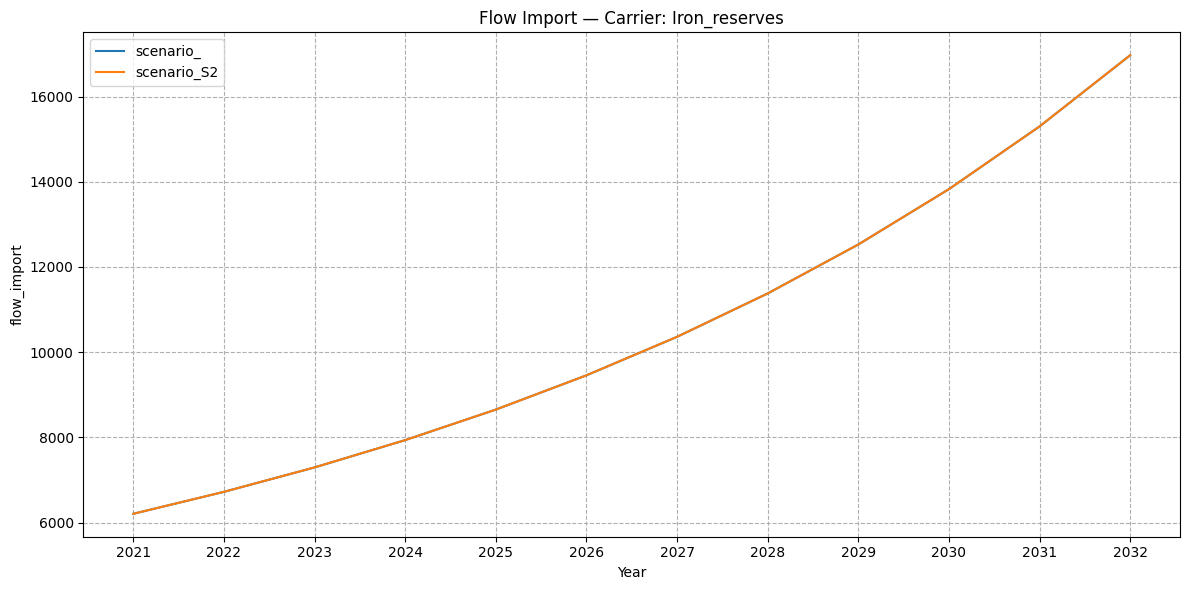

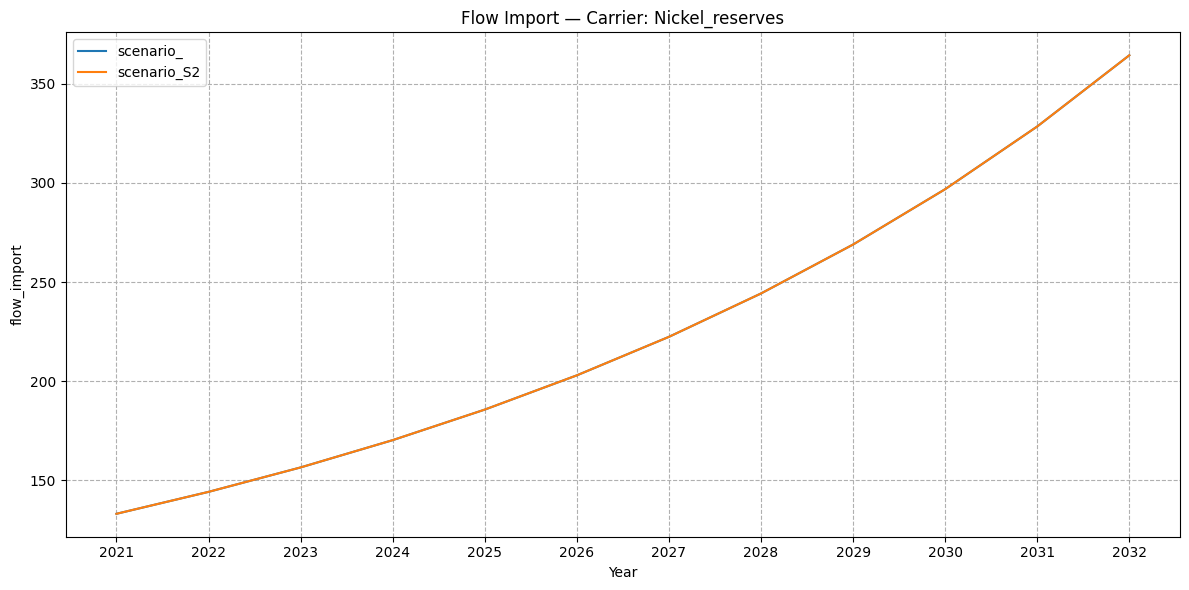

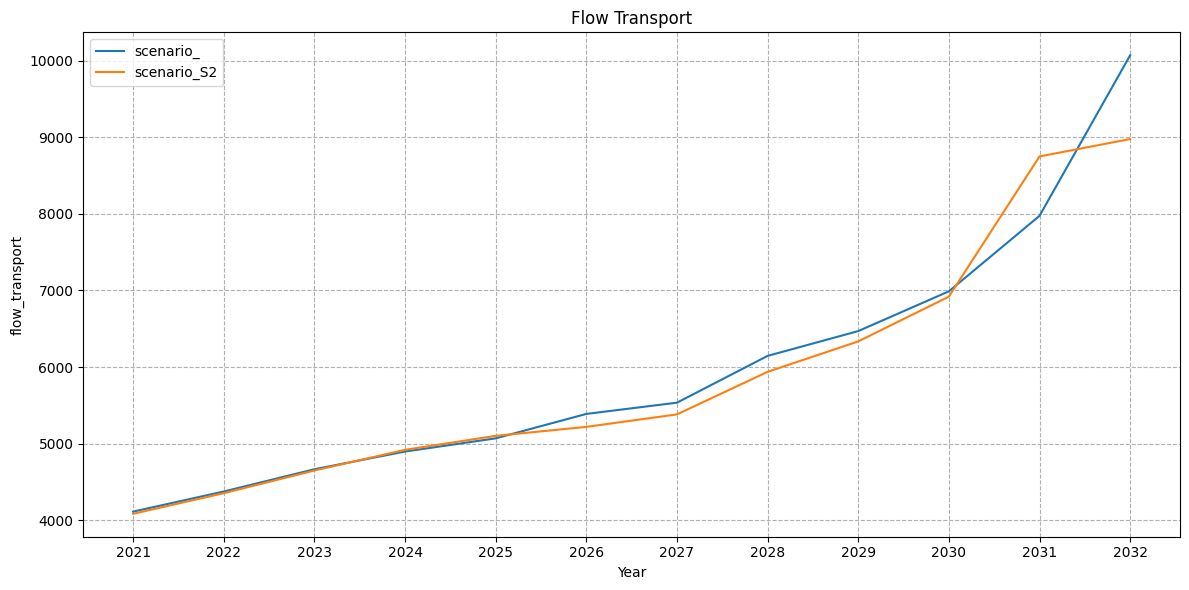

⚠️ Error processing 'net_present_cost': 'scenario'
⚠️ Error processing 'regional_cost_total': 'scenario'


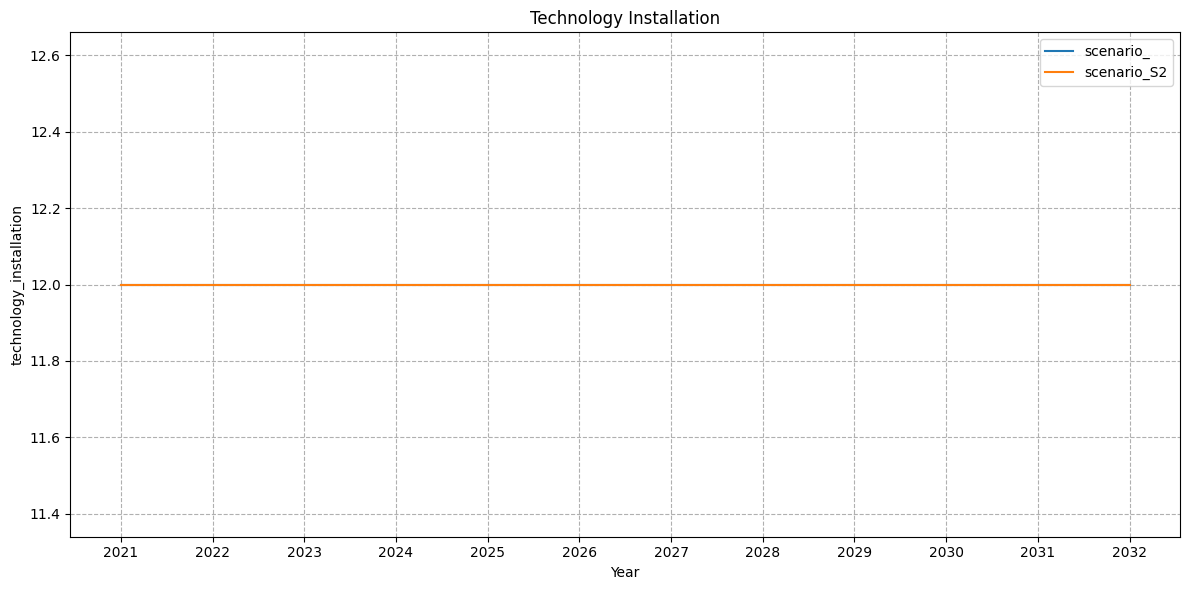

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from zen_garden.postprocess.results import Results

# Load r1 results
dataset_name_1 = 'ZEN-Model_HP'
output_path_1 = os.path.join("outputs", dataset_name_1)
r1 = Results(output_path_1)

# Target variables
variables = [
    'capacity', 'capacity_addition', 'capacity_approximation', 'capacity_investment',
    'capacity_previous', 'capex_approximation', 'capex_yearly', 'carbon_emissions_annual',
    'carbon_emissions_annual_overshoot', 'carbon_emissions_budget_overshoot',
    'carbon_emissions_carrier', 'carbon_emissions_carrier_total', 'carbon_emissions_cumulative',
    'carbon_emissions_technology', 'carbon_emissions_technology_total', 'cost_capex',
    'cost_capex_total', 'cost_carbon_emissions_total', 'cost_carrier', 'cost_carrier_total',
    'cost_opex', 'cost_opex_total', 'cost_opex_yearly', 'cost_shed_demand', 'cost_total',
    'flow_conversion_input', 'flow_conversion_output', 'flow_export', 'flow_import',
    'flow_storage_charge', 'flow_storage_discharge', 'flow_transport', 'flow_transport_loss',
    'net_present_cost', 'regional_cost_total', 'shed_demand', 'storage_level',
    'technology_installation'
]

# Plot each variable across all scenarios
for var in variables:
    try:
        df = r1.get_full_ts(var).reset_index()
        df = df.rename(columns={"level_0": "scenario"})

        df = df[df["scenario"].isin(["scenario_", "scenario_S2"])]

        scenarios = df["scenario"].unique()
        time_cols = [col for col in df.columns if isinstance(col, (int, float))]

        # Determine grouping key
        group_key = "carrier" if "carrier" in df.columns else "node" if "node" in df.columns else None

        if group_key:
            unique_keys = df[group_key].unique()

            for key in unique_keys:
                df_key = df[df[group_key] == key]

                grouped = df_key.groupby("scenario")[time_cols].sum()

                # Skip if all values are zero
                if (grouped.sum(axis=1) == 0).all():
                    continue

                plt.figure(figsize=(12, 6))
                for scenario in scenarios:
                    if scenario in grouped.index:
                        plt.plot(time_cols, grouped.loc[scenario], label=scenario)

                plt.title(f"{var.replace('_', ' ').title()} — {group_key.capitalize()}: {key}")
                plt.xlabel("Year")
                plt.ylabel(var)
                plt.grid(True, linestyle="--")
                plt.legend()
                plt.tight_layout()

                xticks_labels = [str(2021 + i) for i in range(len(time_cols))]
                plt.xticks(ticks=time_cols, labels=xticks_labels)

                plt.show()

        else:
            grouped = df.groupby("scenario")[time_cols].sum()

            # Skip if all values are zero
            if (grouped.sum(axis=1) == 0).all():
                continue

            plt.figure(figsize=(12, 6))
            for scenario in scenarios:
                if scenario in grouped.index:
                    plt.plot(time_cols, grouped.loc[scenario], label=scenario)

            plt.title(f"{var.replace('_', ' ').title()}")
            plt.xlabel("Year")
            plt.ylabel(var)
            plt.grid(True, linestyle="--")
            plt.legend()
            plt.tight_layout()

            xticks_labels = [str(2021 + i) for i in range(len(time_cols))]
            plt.xticks(ticks=time_cols, labels=xticks_labels)

            plt.show()

    except Exception as e:
        print(f"⚠️ Error processing '{var}': {e}")